In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

In [2]:
path = "C://Users//shadj//Desktop//Research//Code//app_data.xlsx"
df = pd.read_excel(path)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 58 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               781 non-null    float64
 1   BMI                               755 non-null    float64
 2   Sex                               780 non-null    object 
 3   Height                            756 non-null    float64
 4   Weight                            779 non-null    float64
 5   Length_of_Stay                    778 non-null    float64
 6   Management                        781 non-null    object 
 7   Severity                          781 non-null    object 
 8   Diagnosis_Presumptive             780 non-null    object 
 9   Diagnosis                         780 non-null    object 
 10  Alvarado_Score                    730 non-null    float64
 11  Paedriatic_Appendicitis_Score     730 non-null    float64
 12  Appendix

In [3]:
df["Diagnosis"].value_counts()

appendicitis       463
no appendicitis    317
Name: Diagnosis, dtype: int64

In [4]:
df.shape

(782, 58)

In [5]:
# from sklearn.model_selection import train_test_split
# df.loc[:,"Diagnosis"].dropna(inplace=True)
# df["Diagnosis"].value_counts(dropna=False)
# #df["Diagnosis"] = df[df["Diagnosis"]=="appendicitis"].astype(int)

In [6]:
#checking the value of Diagnosis Column
df['Diagnosis'].value_counts(dropna = False)


appendicitis       463
no appendicitis    317
NaN                  2
Name: Diagnosis, dtype: int64

In [7]:
# removing the rows whose diagnosis column is nan
df = df[df['Diagnosis'].notna()]
df['Diagnosis'].value_counts(dropna = False)

appendicitis       463
no appendicitis    317
Name: Diagnosis, dtype: int64

In [8]:
#converting the diagnosis value to int type
df["Diagnosis"] = (df['Diagnosis']=='appendicitis').astype(int)

In [9]:
# correlation of different columns with each other
df.corr()

C:\Users\shadj\AppData\Local\Temp\ipykernel_21828\3540467011.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.corr()


,Age,BMI,Height,Weight,Length_of_Stay,Diagnosis,Alvarado_Score,Paedriatic_Appendicitis_Score,Appendix_Diameter,Body_Temperature,WBC_Count,Neutrophil_Percentage,Segmented_Neutrophils,RBC_Count,Hemoglobin,RDW,Thrombocyte_Count,CRP,US_Number
Age,1.000000,0.480260,0.865212,0.766366,-0.103958,-0.088758,-0.181370,-0.127890,-0.030214,-0.290765,-0.248400,-0.177806,-0.450627,0.043015,0.256888,-0.011832,-0.261943,-0.130322,0.046207
BMI,0.480260,1.000000,0.462740,0.859202,-0.045762,-0.124772,-0.121359,-0.100005,0.040996,-0.151558,-0.122949,-0.183794,-0.217881,0.073769,0.175787,0.024529,-0.035245,-0.068655,0.043407
Height,0.865212,0.462740,1.000000,0.829438,-0.108980,-0.064345,-0.134157,-0.107983,-0.006397,-0.232372,-0.201797,-0.129100,-0.346772,0.078383,0.375145,-0.021228,-0.274992,-0.128182,0.002838
Weight,0.766366,0.859202,0.829438,1.000000,-0.066928,-0.099791,-0.146741,-0.121757,0.037628,-0.210826,-0.179033,-0.184130,-0.284693,0.089732,0.239662,0.003105,-0.172860,-0.092634,0.023028
Length_of_Stay,-0.103958,-0.045762,-0.108980,-0.066928,1.000000,0.385103,0.310115,0.227738,0.301530,0.226218,0.300919,0.233578,0.129662,-0.083149,-0.073525,0.084017,0.099924,0.524018,-0.118864
Diagnosis,-0.088758,-0.124772,-0.064345,-0.099791,0.385103,1.000000,0.419104,0.350888,0.629298,0.155629,0.361929,0.354624,0.538303,-0.026141,0.001865,0.057883,0.008935,0.284090,-0.241541
Alvarado_Score,-0.181370,-0.121359,-0.134157,-0.146741,0.310115,0.419104,1.000000,0.832473,0.337497,0.376022,0.639642,0.701133,0.699436,-0.006242,-0.052610,0.059918,0.068806,0.332292,-0.059370
Paedriatic_Appendicitis_Score,-0.127890,-0.100005,-0.107983,-0.121757,0.227738,0.350888,0.832473,1.000000,0.264968,0.299691,0.486760,0.554610,0.508287,-0.005896,-0.056656,0.020818,0.033673,0.266233,0.026625
Appendix_Diameter,-0.030214,0.040996,-0.006397,0.037628,0.301530,0.629298,0.337497,0.264968,1.000000,0.086271,0.333982,0.340236,0.373796,-0.063712,-0.004960,0.065832,0.039110,0.268492,-0.092364
Body_Temperature,-0.290765,-0.151558,-0.232372,-0.210826,0.226218,0.155629,0.376022,0.299691,0.086271,1.000000,0.273795,0.316383,0.152790,-0.038630,-0.071117,-0.010618,0.012231,0.318427,-0.231202


In [10]:
#  correlation of our output column with other columns
df.corr()['Diagnosis']

C:\Users\shadj\AppData\Local\Temp\ipykernel_21828\3928385209.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.corr()['Diagnosis']


Age                             -0.088758
BMI                             -0.124772
Height                          -0.064345
Weight                          -0.099791
Length_of_Stay                   0.385103
Diagnosis                        1.000000
Alvarado_Score                   0.419104
Paedriatic_Appendicitis_Score    0.350888
Appendix_Diameter                0.629298
Body_Temperature                 0.155629
WBC_Count                        0.361929
Neutrophil_Percentage            0.354624
Segmented_Neutrophils            0.538303
RBC_Count                       -0.026141
Hemoglobin                       0.001865
RDW                              0.057883
Thrombocyte_Count                0.008935
CRP                              0.284090
US_Number                       -0.241541
Name: Diagnosis, dtype: float64

In [11]:
# list of columns with contains data of the ultrasound and have very few non na values
US_columns = ['US_Performed','Appendix_on_US','US_Number','Appendix_Wall_Layers','Target_Sign','Perfusion',"Surrounding_Tissue_Reaction",
              "Pathological_Lymph_Nodes","Lymph_Nodes_Location","Bowel_Wall_Thickening","Ileus","Coprostasis","Meteorism","Enteritis","Appendicolith",
               "Perforation","Appendicular_Abscess","Abscess_Location","Conglomerate_of_Bowel_Loops","Gynecological_Findings"]

In [12]:
# since this is early diagnosing therfore assuming that the US is not performed
# Hence removing all the columns that contains information of an ultrasound
df.drop(US_columns,axis=1,inplace=True)

In [13]:
df

,Age,BMI,Sex,Height,Weight,Length_of_Stay,Management,Severity,Diagnosis_Presumptive,Diagnosis,...,Ketones_in_Urine,RBC_in_Urine,WBC_in_Urine,CRP,Dysuria,Stool,Peritonitis,Psoas_Sign,Ipsilateral_Rebound_Tenderness,Free_Fluids
0,12.680000,16.900000,female,148.0,37.0,3.0,conservative,uncomplicated,appendicitis,1,...,++,+,no,0.0,no,normal,no,yes,no,no
1,14.100000,31.900000,male,147.0,69.5,2.0,conservative,uncomplicated,appendicitis,0,...,no,no,no,3.0,yes,normal,no,yes,no,no
2,14.140000,23.300000,female,163.0,62.0,4.0,conservative,uncomplicated,appendicitis,0,...,no,no,no,3.0,no,constipation,no,yes,no,no
3,16.370000,20.600000,female,165.0,56.0,3.0,conservative,uncomplicated,appendicitis,0,...,no,no,no,0.0,yes,normal,no,yes,no,no
4,11.080000,16.900000,female,163.0,45.0,3.0,conservative,uncomplicated,appendicitis,1,...,no,no,no,0.0,no,constipation,no,yes,no,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
777,12.413415,25.250476,female,166.5,70.0,4.0,primary surgical,uncomplicated,appendicitis,1,...,NaN,NaN,NaN,71.0,no,diarrhea,local,yes,NaN,no
778,17.092402,20.429418,female,158.0,51.0,6.0,secondary surgical,complicated,appendicitis,1,...,NaN,NaN,NaN,245.0,no,normal,local,no,NaN,no
779,14.992471,19.909972,female,152.0,46.0,4.0,primary surgical,uncomplicated,appendicitis,1,...,no,no,no,2.0,yes,normal,no,no,no,yes
780,7.195072,14.295549,male,129.3,23.9,5.0,primary surgical,uncomplicated,appendicitis,1,...,+++,no,no,8.0,no,normal,local,no,no,yes


In [14]:
#This is the list of other target or output columns
target_cols = ["Diagnosis_Presumptive","Management","Severity","Length_of_Stay"]

In [15]:
# REmoving other target columns since they are not necessary
df.drop(target_cols,axis=1,inplace =True)

In [16]:
#information of the remaining dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 780 entries, 0 to 781
Data columns (total 34 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               780 non-null    float64
 1   BMI                               754 non-null    float64
 2   Sex                               779 non-null    object 
 3   Height                            755 non-null    float64
 4   Weight                            778 non-null    float64
 5   Diagnosis                         780 non-null    int32  
 6   Alvarado_Score                    730 non-null    float64
 7   Paedriatic_Appendicitis_Score     730 non-null    float64
 8   Appendix_Diameter                 498 non-null    float64
 9   Migratory_Pain                    773 non-null    object 
 10  Lower_Right_Abd_Pain              774 non-null    object 
 11  Contralateral_Rebound_Tenderness  767 non-null    object 
 12  Coughing

In [17]:
#removing the "Segmented_Neutrophils" Column, Since it had very few values
df.drop("Segmented_Neutrophils",axis=1,inplace=True)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 780 entries, 0 to 781
Data columns (total 33 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               780 non-null    float64
 1   BMI                               754 non-null    float64
 2   Sex                               779 non-null    object 
 3   Height                            755 non-null    float64
 4   Weight                            778 non-null    float64
 5   Diagnosis                         780 non-null    int32  
 6   Alvarado_Score                    730 non-null    float64
 7   Paedriatic_Appendicitis_Score     730 non-null    float64
 8   Appendix_Diameter                 498 non-null    float64
 9   Migratory_Pain                    773 non-null    object 
 10  Lower_Right_Abd_Pain              774 non-null    object 
 11  Contralateral_Rebound_Tenderness  767 non-null    object 
 12  Coughing

<h2>Selecting only those rows which have no nan values : </h2>

In [19]:
df2 = df.dropna().copy()

In [20]:
df2

,Age,BMI,Sex,Height,Weight,Diagnosis,Alvarado_Score,Paedriatic_Appendicitis_Score,Appendix_Diameter,Migratory_Pain,...,Ketones_in_Urine,RBC_in_Urine,WBC_in_Urine,CRP,Dysuria,Stool,Peritonitis,Psoas_Sign,Ipsilateral_Rebound_Tenderness,Free_Fluids
0,12.680000,16.900000,female,148.0,37.0,1,4.0,3.0,7.1,no,...,++,+,no,0.0,no,normal,no,yes,no,no
4,11.080000,16.900000,female,163.0,45.0,1,5.0,6.0,7.0,no,...,no,no,no,0.0,no,constipation,no,yes,no,no
8,7.900000,15.700000,male,131.0,26.7,0,7.0,6.0,3.7,no,...,+++,+,no,20.0,no,normal,no,no,no,yes
9,14.340000,14.900000,male,174.0,45.5,1,4.0,4.0,8.0,no,...,no,no,no,0.0,no,normal,no,no,no,no
10,11.870000,15.700000,male,147.0,34.0,1,8.0,9.0,9.0,yes,...,no,no,no,17.0,no,normal,no,no,no,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
729,12.470910,15.373934,female,142.0,31.0,1,9.0,6.0,7.0,yes,...,no,no,no,0.0,no,normal,local,yes,no,yes
754,13.828884,23.828125,male,160.0,61.0,1,6.0,4.0,12.0,no,...,no,no,no,4.0,no,normal,local,yes,no,no
764,7.990000,13.550000,female,128.0,22.1,1,5.0,4.0,5.0,no,...,+++,no,no,0.0,no,constipation,no,no,no,no
768,11.548255,17.529432,female,152.0,40.5,1,9.0,7.0,10.0,no,...,+++,+,no,5.0,no,diarrhea,local,no,no,yes


In [21]:
df2.columns

Index(['Age', 'BMI', 'Sex', 'Height', 'Weight', 'Diagnosis', 'Alvarado_Score',
       'Paedriatic_Appendicitis_Score', 'Appendix_Diameter', 'Migratory_Pain',
       'Lower_Right_Abd_Pain', 'Contralateral_Rebound_Tenderness',
       'Coughing_Pain', 'Nausea', 'Loss_of_Appetite', 'Body_Temperature',
       'WBC_Count', 'Neutrophil_Percentage', 'Neutrophilia', 'RBC_Count',
       'Hemoglobin', 'RDW', 'Thrombocyte_Count', 'Ketones_in_Urine',
       'RBC_in_Urine', 'WBC_in_Urine', 'CRP', 'Dysuria', 'Stool',
       'Peritonitis', 'Psoas_Sign', 'Ipsilateral_Rebound_Tenderness',
       'Free_Fluids'],
      dtype='object')

In [22]:
df2["WBC_in_Urine"].value_counts()

no     206
+       22
++       7
+++      3
Name: WBC_in_Urine, dtype: int64

In [23]:
df2["Sex"].value_counts()

male      124
female    114
Name: Sex, dtype: int64

In [24]:
df2["Diagnosis"].value_counts()

1    157
0     81
Name: Diagnosis, dtype: int64

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 780 entries, 0 to 781
Data columns (total 33 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               780 non-null    float64
 1   BMI                               754 non-null    float64
 2   Sex                               779 non-null    object 
 3   Height                            755 non-null    float64
 4   Weight                            778 non-null    float64
 5   Diagnosis                         780 non-null    int32  
 6   Alvarado_Score                    730 non-null    float64
 7   Paedriatic_Appendicitis_Score     730 non-null    float64
 8   Appendix_Diameter                 498 non-null    float64
 9   Migratory_Pain                    773 non-null    object 
 10  Lower_Right_Abd_Pain              774 non-null    object 
 11  Contralateral_Rebound_Tenderness  767 non-null    object 
 12  Coughing

In [26]:
df2["Sex"].value_counts()

male      124
female    114
Name: Sex, dtype: int64

In [27]:
df2["Sex"] = (df["Sex"]=="male").astype(int)

In [28]:
df2['Migratory_Pain']= (df2['Migratory_Pain']=='yes').astype(int)

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 780 entries, 0 to 781
Data columns (total 33 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               780 non-null    float64
 1   BMI                               754 non-null    float64
 2   Sex                               779 non-null    object 
 3   Height                            755 non-null    float64
 4   Weight                            778 non-null    float64
 5   Diagnosis                         780 non-null    int32  
 6   Alvarado_Score                    730 non-null    float64
 7   Paedriatic_Appendicitis_Score     730 non-null    float64
 8   Appendix_Diameter                 498 non-null    float64
 9   Migratory_Pain                    773 non-null    object 
 10  Lower_Right_Abd_Pain              774 non-null    object 
 11  Contralateral_Rebound_Tenderness  767 non-null    object 
 12  Coughing

In [30]:
df2["Lower_Right_Abd_Pain"].value_counts()

yes    228
no      10
Name: Lower_Right_Abd_Pain, dtype: int64

In [31]:
df2["Lower_Right_Abd_Pain"] =(df["Lower_Right_Abd_Pain"]=="yes").astype(int)
df2["Lower_Right_Abd_Pain"].value_counts()

1    228
0     10
Name: Lower_Right_Abd_Pain, dtype: int64

In [32]:
df2["Contralateral_Rebound_Tenderness"].value_counts()

no     149
yes     89
Name: Contralateral_Rebound_Tenderness, dtype: int64

In [33]:
df2["Contralateral_Rebound_Tenderness"] = (df["Contralateral_Rebound_Tenderness"]=='yes').astype(int)
df2['Contralateral_Rebound_Tenderness'].value_counts()

0    149
1     89
Name: Contralateral_Rebound_Tenderness, dtype: int64

In [34]:
df2["Coughing_Pain"].value_counts(dropna = False)

no     163
yes     75
Name: Coughing_Pain, dtype: int64

In [35]:
df2["Coughing_Pain"] = (df2["Coughing_Pain"] =="yes").astype(int)
df2["Coughing_Pain"].value_counts()

0    163
1     75
Name: Coughing_Pain, dtype: int64

In [36]:
df2["Nausea"].value_counts(dropna = False)

yes    132
no     106
Name: Nausea, dtype: int64

In [37]:
df2["Nausea"] = (df["Nausea"]=='yes').astype(int)
df2["Nausea"].value_counts()

1    132
0    106
Name: Nausea, dtype: int64

In [38]:
df2["Loss_of_Appetite"].value_counts(dropna= False)

yes    121
no     117
Name: Loss_of_Appetite, dtype: int64

In [39]:
df2["Loss_of_Appetite"] = (df2["Loss_of_Appetite"]=='yes').astype(int)
df2["Loss_of_Appetite"].value_counts()

1    121
0    117
Name: Loss_of_Appetite, dtype: int64

In [40]:
df2["Neutrophilia"].value_counts(dropna = False)

no     138
yes    100
Name: Neutrophilia, dtype: int64

In [41]:
df2["Neutrophilia"] = (df["Neutrophilia"]== 'yes').astype(int)
df2["Neutrophilia"].value_counts()

0    138
1    100
Name: Neutrophilia, dtype: int64

In [42]:
df2["Ketones_in_Urine"].value_counts(dropna = False)

no     148
+++     47
+       29
++      14
Name: Ketones_in_Urine, dtype: int64

In [43]:
from sklearn.preprocessing import OrdinalEncoder
enc = OrdinalEncoder(categories=[['no','+','++','+++']])
enc.fit([['no'], ['+'], ['++'],['+++']])                                 
df2["Ketones_in_Urine"] = enc.fit_transform(df2[["Ketones_in_Urine"]])
df2["Ketones_in_Urine"].value_counts(dropna = False)

0.0    148
3.0     47
1.0     29
2.0     14
Name: Ketones_in_Urine, dtype: int64

In [44]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 238 entries, 0 to 780
Data columns (total 33 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               238 non-null    float64
 1   BMI                               238 non-null    float64
 2   Sex                               238 non-null    int32  
 3   Height                            238 non-null    float64
 4   Weight                            238 non-null    float64
 5   Diagnosis                         238 non-null    int32  
 6   Alvarado_Score                    238 non-null    float64
 7   Paedriatic_Appendicitis_Score     238 non-null    float64
 8   Appendix_Diameter                 238 non-null    float64
 9   Migratory_Pain                    238 non-null    int32  
 10  Lower_Right_Abd_Pain              238 non-null    int32  
 11  Contralateral_Rebound_Tenderness  238 non-null    int32  
 12  Coughing

In [45]:
df2["RBC_in_Urine"].value_counts(dropna = False)

no     190
+       37
+++      7
++       4
Name: RBC_in_Urine, dtype: int64

In [46]:
enc = OrdinalEncoder(categories=[['no','+','++','+++']])
enc.fit([['no'], ['+'], ['++'],['+++']])                                 
df2["RBC_in_Urine"] = enc.fit_transform(df2[["RBC_in_Urine"]])
df2["RBC_in_Urine"].value_counts(dropna = False)

0.0    190
1.0     37
3.0      7
2.0      4
Name: RBC_in_Urine, dtype: int64

In [47]:
df2["WBC_in_Urine"].value_counts(dropna= False)

no     206
+       22
++       7
+++      3
Name: WBC_in_Urine, dtype: int64

In [48]:
enc = OrdinalEncoder(categories=[['no','+','++','+++']])
enc.fit([['no'], ['+'], ['++'],['+++']])                                 
df2["WBC_in_Urine"] = enc.fit_transform(df2[["WBC_in_Urine"]])
df2["WBC_in_Urine"].value_counts(dropna = False)

0.0    206
1.0     22
2.0      7
3.0      3
Name: WBC_in_Urine, dtype: int64

In [49]:
df2["Dysuria"].value_counts(dropna= False)

no     227
yes     11
Name: Dysuria, dtype: int64

In [50]:
df2["Dysuria"] = (df2["Dysuria"]=='yes').astype(int)
df2["Dysuria"].value_counts()

0    227
1     11
Name: Dysuria, dtype: int64

In [51]:
df2["Stool"].value_counts()
#will do one hot encoding here

normal          174
diarrhea         37
constipation     27
Name: Stool, dtype: int64

In [52]:
enc = OrdinalEncoder(categories=[['constipation','normal','diarrhea']])
enc.fit([['constipation'], ['normal'], ['diarrhea']])                                 
df2["Stool"] = enc.fit_transform(df2[["Stool"]])
df2["Stool"].value_counts(dropna = False)

1.0    174
2.0     37
0.0     27
Name: Stool, dtype: int64

In [53]:
df2["Peritonitis"].value_counts()

no             189
local           43
generalized      6
Name: Peritonitis, dtype: int64

In [54]:
enc = OrdinalEncoder(categories=[['no','local','generalized']])
enc.fit([['no'], ['local'], ['generalized']])                                 
df2["Peritonitis"] = enc.fit_transform(df2[["Peritonitis"]])
df2["Peritonitis"].value_counts(dropna = False)

0.0    189
1.0     43
2.0      6
Name: Peritonitis, dtype: int64

In [55]:
df2["Diagnosis"].corr(df2["Peritonitis"])

0.1618742249964222

In [56]:
#Adding a binary Peritonitis column since it has a better correlation with the target variable
df2["Peritonitis_binary"] = (df2["Peritonitis"]!=0).astype(int)

In [57]:
#dropping the Peritonitis Columns
df2.drop(["Peritonitis"],axis=1, inplace =True)

In [58]:
df2["Diagnosis"].corr(df2["Peritonitis_binary"])

0.19028246913072036

In [59]:
df2["Psoas_Sign"].value_counts()

no     160
yes     78
Name: Psoas_Sign, dtype: int64

In [60]:
df2["Psoas_Sign"]= (df2["Psoas_Sign"]=='yes').astype(int)

In [61]:
df2["Ipsilateral_Rebound_Tenderness"].value_counts()

no     226
yes     12
Name: Ipsilateral_Rebound_Tenderness, dtype: int64

In [62]:
df2["Ipsilateral_Rebound_Tenderness"] = (df2["Ipsilateral_Rebound_Tenderness"]=='yes').astype(int)

In [63]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 238 entries, 0 to 780
Data columns (total 33 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               238 non-null    float64
 1   BMI                               238 non-null    float64
 2   Sex                               238 non-null    int32  
 3   Height                            238 non-null    float64
 4   Weight                            238 non-null    float64
 5   Diagnosis                         238 non-null    int32  
 6   Alvarado_Score                    238 non-null    float64
 7   Paedriatic_Appendicitis_Score     238 non-null    float64
 8   Appendix_Diameter                 238 non-null    float64
 9   Migratory_Pain                    238 non-null    int32  
 10  Lower_Right_Abd_Pain              238 non-null    int32  
 11  Contralateral_Rebound_Tenderness  238 non-null    int32  
 12  Coughing

In [64]:
df2.corr()["Diagnosis"]

C:\Users\shadj\AppData\Local\Temp\ipykernel_21828\3919710716.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df2.corr()["Diagnosis"]


Age                                -0.015028
BMI                                -0.014656
Sex                                 0.056833
Height                             -0.020931
Weight                             -0.019917
Diagnosis                           1.000000
Alvarado_Score                      0.396722
Paedriatic_Appendicitis_Score       0.330840
Appendix_Diameter                   0.657866
Migratory_Pain                      0.189311
Lower_Right_Abd_Pain                0.070571
Contralateral_Rebound_Tenderness    0.115277
Coughing_Pain                       0.086377
Nausea                              0.212755
Loss_of_Appetite                    0.091894
Body_Temperature                    0.083812
WBC_Count                           0.301403
Neutrophil_Percentage               0.247917
Neutrophilia                        0.180261
RBC_Count                          -0.074309
Hemoglobin                         -0.055650
RDW                                 0.061406
Thrombocyt

C:\Users\shadj\AppData\Local\Temp\ipykernel_21828\231157439.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df2.corr())


<AxesSubplot: >

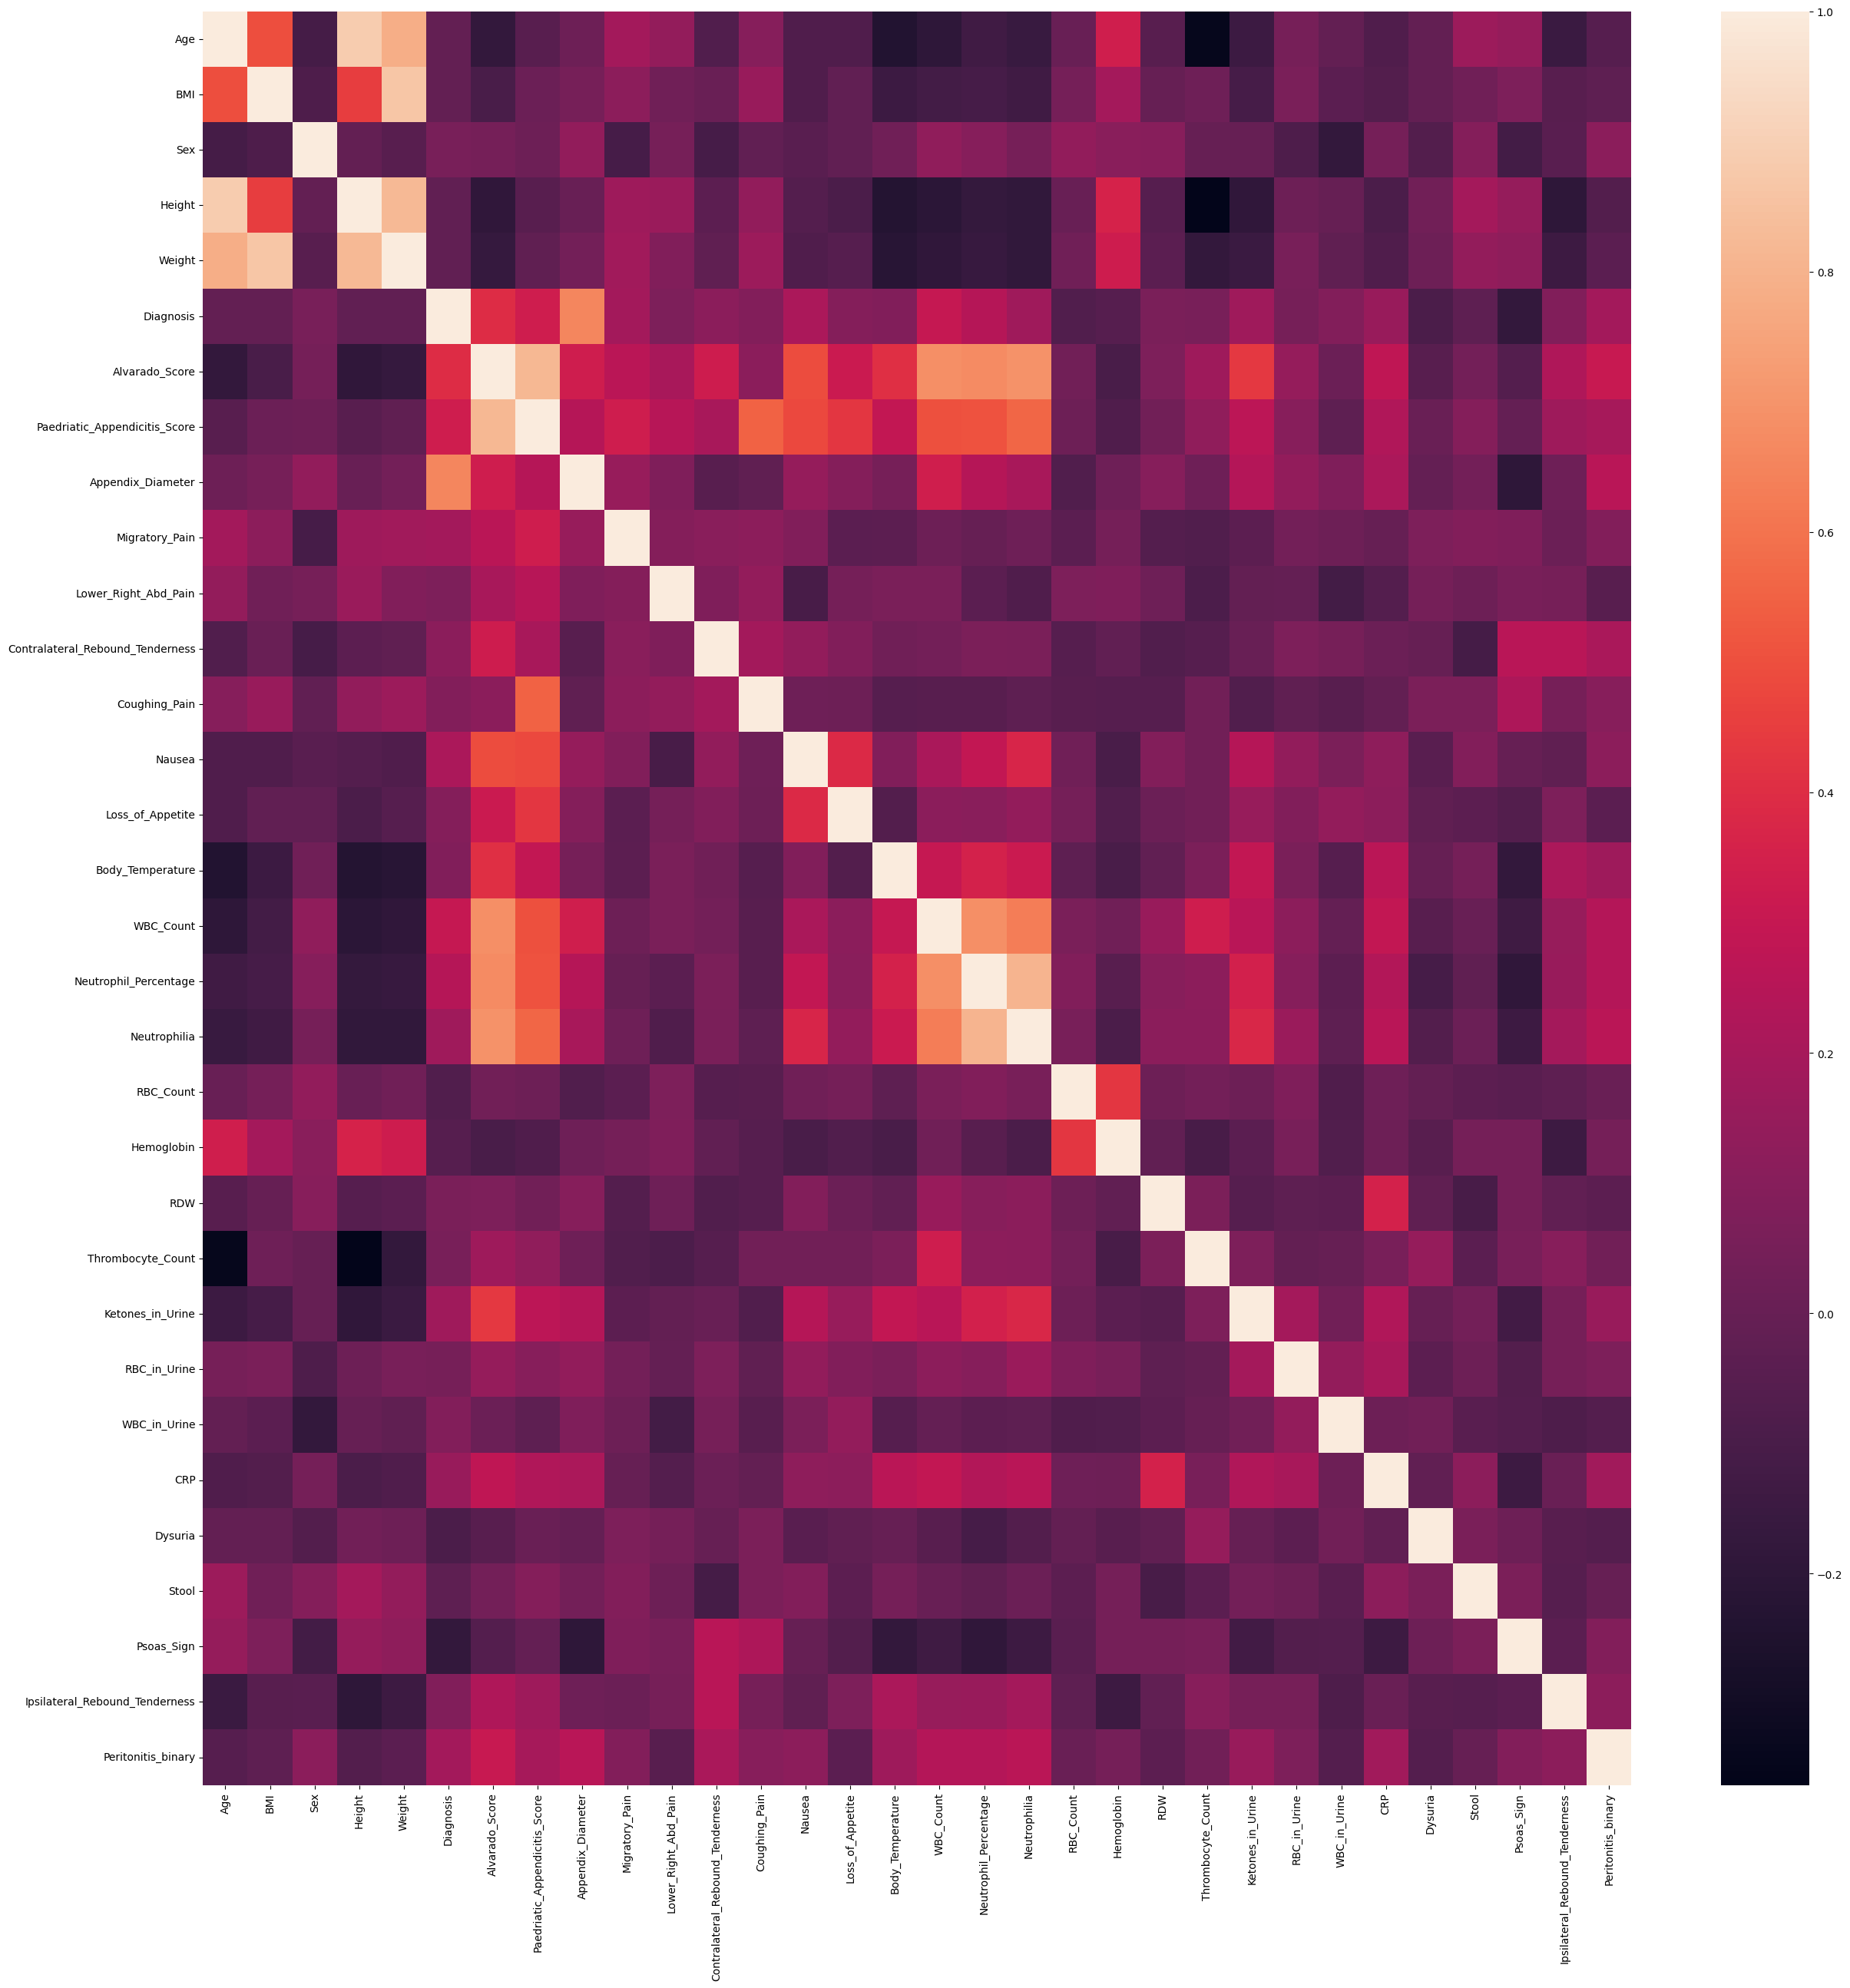

In [65]:
plt.figure(figsize=(30,30))
sns.heatmap(df2.corr())

In [66]:
df2["Free_Fluids"] =(df["Free_Fluids"]=='yes').astype(int)

In [67]:
df2["Diagnosis"].value_counts()

1    157
0     81
Name: Diagnosis, dtype: int64

In [68]:
# dsafsf

In [69]:
y = df2.loc[:,"Diagnosis"]
y.value_counts()
x = df2.loc[:,df2.columns!='Diagnosis']
x.shape

(238, 32)

In [70]:
from sklearn.model_selection import train_test_split

# Applying Dimensionality Reduction (PCA)

In [71]:
from sklearn.decomposition import PCA
pca = PCA(n_components=0.95)
x_reduced = pca.fit_transform(x)

In [72]:
x_train, x_test , y_train, y_test = train_test_split(x_reduced,y,test_size=0.2,random_state=42)

In [73]:
x_train.shape

(190, 3)

In [74]:
y_train.shape

(190,)

In [75]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier()
model = model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.35      0.35      0.35        17
           1       0.65      0.65      0.65        31

    accuracy                           0.54        48
   macro avg       0.50      0.50      0.50        48
weighted avg       0.54      0.54      0.54        48



In [76]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate

X= x_reduced

scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

FIT_TIME - Mean: 0.00 ± 0.00
SCORE_TIME - Mean: 0.01 ± 0.00
TEST_ACCURACY - Mean: 0.64 ± 0.09
TEST_F1 - Mean: 0.75 ± 0.08
TEST_ROC_AUC - Mean: 0.57 ± 0.07
TEST_AVERAGE_PRECISION - Mean: 0.71 ± 0.05
TEST_PRECISION - Mean: 0.69 ± 0.08
TEST_RECALL - Mean: 0.82 ± 0.10


In [77]:
from sklearn.model_selection import KFold
from sklearn.metrics import average_precision_score
import numpy as np

# Assuming you have your data and model ready
# X = your_data  # Features
# y = your_labels  # Target variable
X = x_reduced
# X = pd.DataFrame(X)
# y = pd.DataFrame(y)
def calulatuion():
    # Initialize KFold with 5 folds
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    aupr_scores = []  # List to store AUPR scores for each fold

    for train_index, test_index in kf.split(X):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Fit your model
        model.fit(X_train, y_train)

        # Predict probabilities for positive class
        y_pred_proba = model.predict_proba(X_test)[:, 1]

        # Calculate AUPR for this fold
        aupr = average_precision_score(y_test, y_pred_proba)
        aupr_scores.append(aupr)

    # Calculate average AUPR across all folds
    average_aupr = np.mean(aupr_scores)
    std_aupr = np.std(aupr_scores)

    print(f'Average AUPR: {average_aupr:.4f} ± {std_aupr:.2f}')
calulatuion()

Average AUPR: 0.7080 ± 0.05


In [78]:
from sklearn.naive_bayes import GaussianNB
model = GaussianNB()
model = model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.46      0.65      0.54        17
           1       0.75      0.58      0.65        31

    accuracy                           0.60        48
   macro avg       0.60      0.61      0.60        48
weighted avg       0.65      0.60      0.61        48



In [79]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate

X= x_reduced

scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

FIT_TIME - Mean: 0.00 ± 0.00
SCORE_TIME - Mean: 0.01 ± 0.00
TEST_ACCURACY - Mean: 0.54 ± 0.08
TEST_F1 - Mean: 0.59 ± 0.16
TEST_ROC_AUC - Mean: 0.58 ± 0.06
TEST_AVERAGE_PRECISION - Mean: 0.75 ± 0.04
TEST_PRECISION - Mean: 0.70 ± 0.07
TEST_RECALL - Mean: 0.57 ± 0.24


In [80]:
from sklearn.model_selection import KFold
from sklearn.metrics import average_precision_score
import numpy as np

# Assuming you have your data and model ready
# X = your_data  # Features
# y = your_labels  # Target variable
X = x_reduced
# X = pd.DataFrame(X)
# y = pd.DataFrame(y)
def calulatuion():
    # Initialize KFold with 5 folds
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    aupr_scores = []  # List to store AUPR scores for each fold

    for train_index, test_index in kf.split(X):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Fit your model
        model.fit(X_train, y_train)

        # Predict probabilities for positive class
        y_pred_proba = model.predict_proba(X_test)[:, 1]

        # Calculate AUPR for this fold
        aupr = average_precision_score(y_test, y_pred_proba)
        aupr_scores.append(aupr)

    # Calculate average AUPR across all folds
    average_aupr = np.mean(aupr_scores)
    std_aupr = np.std(aupr_scores)

    print(f'Average AUPR: {average_aupr:.4f} ± {std_aupr:.2f}')
calulatuion()

Average AUPR: 0.7451 ± 0.04


In [81]:
from sklearn.svm import SVC
model = SVC()
model = model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.67      0.12      0.20        17
           1       0.67      0.97      0.79        31

    accuracy                           0.67        48
   macro avg       0.67      0.54      0.49        48
weighted avg       0.67      0.67      0.58        48



In [82]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate

X= x_reduced

scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

FIT_TIME - Mean: 0.00 ± 0.00
SCORE_TIME - Mean: 0.01 ± 0.00
TEST_ACCURACY - Mean: 0.65 ± 0.07
TEST_F1 - Mean: 0.78 ± 0.06
TEST_ROC_AUC - Mean: 0.60 ± 0.06
TEST_AVERAGE_PRECISION - Mean: 0.73 ± 0.09
TEST_PRECISION - Mean: 0.66 ± 0.07
TEST_RECALL - Mean: 0.94 ± 0.05


In [83]:
# from sklearn.model_selection import KFold
# from sklearn.metrics import average_precision_score
# import numpy as np

# # Assuming you have your data and model ready
# # X = your_data  # Features
# # y = your_labels  # Target variable
# X = x_reduced
# # X = pd.DataFrame(X)
# # y = pd.DataFrame(y)
# def calulatuion():
#     # Initialize KFold with 5 folds
#     kf = KFold(n_splits=5, shuffle=True, random_state=42)

#     aupr_scores = []  # List to store AUPR scores for each fold

#     for train_index, test_index in kf.split(X):
#         X_train, X_test = X[train_index], X[test_index]
#         y_train, y_test = y.iloc[train_index], y.iloc[test_index]

#         # Fit your model
#         model.fit(X_train, y_train)

#         # Predict probabilities for positive class
#         y_pred_proba = model.predict_proba(X_test)[:, 1]

#         # Calculate AUPR for this fold
#         aupr = average_precision_score(y_test, y_pred_proba)
#         aupr_scores.append(aupr)

#     # Calculate average AUPR across all folds
#     average_aupr = np.mean(aupr_scores)
#     std_aupr = np.std(aupr_scores)

#     print(f'Average AUPR: {average_aupr:.4f} ± {std_aupr:.2f}')
# calulatuion()

In [84]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model = model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.47      0.47      0.47        17
           1       0.71      0.71      0.71        31

    accuracy                           0.62        48
   macro avg       0.59      0.59      0.59        48
weighted avg       0.62      0.62      0.63        48



In [85]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate

# x_train = pd.DataFrame(x_train)
# x_test = pd.DataFrame(x_test)
# y_train = pd.DataFrame(y_train)
# y_test = pd.DataFrame(y_test)
X= x_reduced

scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

FIT_TIME - Mean: 0.00 ± 0.00
SCORE_TIME - Mean: 0.01 ± 0.00
TEST_ACCURACY - Mean: 0.62 ± 0.05
TEST_F1 - Mean: 0.71 ± 0.07
TEST_ROC_AUC - Mean: 0.58 ± 0.03
TEST_AVERAGE_PRECISION - Mean: 0.70 ± 0.05
TEST_PRECISION - Mean: 0.71 ± 0.05
TEST_RECALL - Mean: 0.71 ± 0.13


In [86]:
from sklearn.model_selection import KFold
from sklearn.metrics import average_precision_score
import numpy as np

# Assuming you have your data and model ready
# X = your_data  # Features
# y = your_labels  # Target variable
X = x_reduced
# X = pd.DataFrame(X)
# y = pd.DataFrame(y)
def calulatuion():
    # Initialize KFold with 5 folds
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    aupr_scores = []  # List to store AUPR scores for each fold

    for train_index, test_index in kf.split(X):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Fit your model
        model.fit(X_train, y_train)

        # Predict probabilities for positive class
        y_pred_proba = model.predict_proba(X_test)[:, 1]

        # Calculate AUPR for this fold
        aupr = average_precision_score(y_test, y_pred_proba)
        aupr_scores.append(aupr)

    # Calculate average AUPR across all folds
    average_aupr = np.mean(aupr_scores)
    std_aupr = np.std(aupr_scores)

    print(f'Average AUPR: {average_aupr:.4f} ± {std_aupr:.2f}')
calulatuion()

Average AUPR: 0.7080 ± 0.05


In [87]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
model = model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.35      0.43      0.39        14
           1       0.74      0.68      0.71        34

    accuracy                           0.60        48
   macro avg       0.55      0.55      0.55        48
weighted avg       0.63      0.60      0.61        48



In [88]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate
# x_train = pd.DataFrame(x_train)
# x_test = pd.DataFrame(x_test)
# y_train = pd.DataFrame(y_train)
# y_test = pd.DataFrame(y_test)
X= x_reduced

scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    if(v =='fit_time' or v =='score_time'):
          print(f"{v.upper()} - Mean: {mean_score:.4f} ± {std_score:.2f}")
    else:
        print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")


FIT_TIME - Mean: 0.0990 ± 0.00
SCORE_TIME - Mean: 0.0110 ± 0.00
TEST_ACCURACY - Mean: 0.67 ± 0.06
TEST_F1 - Mean: 0.76 ± 0.06
TEST_ROC_AUC - Mean: 0.65 ± 0.03
TEST_AVERAGE_PRECISION - Mean: 0.78 ± 0.05


In [89]:
from sklearn.model_selection import KFold
from sklearn.metrics import average_precision_score
import numpy as np

# Assuming you have your data and model ready
# X = your_data  # Features
# y = your_labels  # Target variable
X = x_reduced
# X = pd.DataFrame(X)
# y = pd.DataFrame(y)
def calulatuion():
    # Initialize KFold with 5 folds
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    aupr_scores = []  # List to store AUPR scores for each fold

    for train_index, test_index in kf.split(X):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Fit your model
        model.fit(X_train, y_train)

        # Predict probabilities for positive class
        y_pred_proba = model.predict_proba(X_test)[:, 1]

        # Calculate AUPR for this fold
        aupr = average_precision_score(y_test, y_pred_proba)
        aupr_scores.append(aupr)

    # Calculate average AUPR across all folds
    average_aupr = np.mean(aupr_scores)
    std_aupr = np.std(aupr_scores)

    print(f'Average AUPR: {average_aupr:.4f} ± {std_aupr:.2f}')
calulatuion()

Average AUPR: 0.7713 ± 0.05


In [90]:
from xgboost import XGBClassifier
# from catboost import CatBoostClassifier
model = XGBClassifier()
model.fit(x_train,y_train,verbose=False)
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.43      0.35      0.39        17
           1       0.68      0.74      0.71        31

    accuracy                           0.60        48
   macro avg       0.55      0.55      0.55        48
weighted avg       0.59      0.60      0.59        48



In [91]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate

X= x_reduced

scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    if(v =='fit_time' or v =='score_time'):
          print(f"{v.upper()} - Mean: {mean_score:.4f} ± {std_score:.2f}")
    else:
        print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")



FIT_TIME - Mean: 0.0306 ± 0.01
SCORE_TIME - Mean: 0.0101 ± 0.00
TEST_ACCURACY - Mean: 0.63 ± 0.03
TEST_F1 - Mean: 0.73 ± 0.04
TEST_ROC_AUC - Mean: 0.63 ± 0.01
TEST_AVERAGE_PRECISION - Mean: 0.79 ± 0.05
TEST_PRECISION - Mean: 0.71 ± 0.05
TEST_RECALL - Mean: 0.77 ± 0.08


In [92]:
from sklearn.model_selection import KFold
from sklearn.metrics import average_precision_score
import numpy as np

# Assuming you have your data and model ready
# X = your_data  # Features
# y = your_labels  # Target variable
X = x_reduced
# X = pd.DataFrame(X)
# y = pd.DataFrame(y)
def calulatuion():
    # Initialize KFold with 5 folds
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    aupr_scores = []  # List to store AUPR scores for each fold

    for train_index, test_index in kf.split(X):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Fit your model
        model.fit(X_train, y_train)

        # Predict probabilities for positive class
        y_pred_proba = model.predict_proba(X_test)[:, 1]

        # Calculate AUPR for this fold
        aupr = average_precision_score(y_test, y_pred_proba)
        aupr_scores.append(aupr)

    # Calculate average AUPR across all folds
    average_aupr = np.mean(aupr_scores)
    std_aupr = np.std(aupr_scores)

    print(f'Average AUPR: {average_aupr:.4f} ± {std_aupr:.2f}')
calulatuion()

Average AUPR: 0.7869 ± 0.05


In [93]:
from lightgbm import LGBMClassifier
model = LGBMClassifier()
model = model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.47      0.47      0.47        17
           1       0.71      0.71      0.71        31

    accuracy                           0.62        48
   macro avg       0.59      0.59      0.59        48
weighted avg       0.62      0.62      0.63        48



In [94]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate

X= x_reduced

scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    if(v =='fit_time' or v =='score_time'):
          print(f"{v.upper()} - Mean: {mean_score:.4f} ± {std_score:.2f}")
    else:
        print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")



FIT_TIME - Mean: 0.0133 ± 0.00
SCORE_TIME - Mean: 0.0095 ± 0.00
TEST_ACCURACY - Mean: 0.65 ± 0.06
TEST_F1 - Mean: 0.74 ± 0.06
TEST_ROC_AUC - Mean: 0.66 ± 0.04
TEST_AVERAGE_PRECISION - Mean: 0.79 ± 0.06
TEST_PRECISION - Mean: 0.73 ± 0.07
TEST_RECALL - Mean: 0.76 ± 0.10


In [95]:
from sklearn.model_selection import KFold
from sklearn.metrics import average_precision_score
import numpy as np

# Assuming you have your data and model ready
# X = your_data  # Features
# y = your_labels  # Target variable
X = x_reduced
# X = pd.DataFrame(X)
# y = pd.DataFrame(y)
def calulatuion():
    # Initialize KFold with 5 folds
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    aupr_scores = []  # List to store AUPR scores for each fold

    for train_index, test_index in kf.split(X):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Fit your model
        model.fit(X_train, y_train)

        # Predict probabilities for positive class
        y_pred_proba = model.predict_proba(X_test)[:, 1]

        # Calculate AUPR for this fold
        aupr = average_precision_score(y_test, y_pred_proba)
        aupr_scores.append(aupr)

    # Calculate average AUPR across all folds
    average_aupr = np.mean(aupr_scores)
    std_aupr = np.std(aupr_scores)

    print(f'Average AUPR: {average_aupr:.4f} ± {std_aupr:.2f}')
calulatuion()

Average AUPR: 0.7904 ± 0.06


In [96]:
from sklearn.ensemble import AdaBoostClassifier
model = AdaBoostClassifier()
model = model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.60      0.53      0.56        17
           1       0.76      0.81      0.78        31

    accuracy                           0.71        48
   macro avg       0.68      0.67      0.67        48
weighted avg       0.70      0.71      0.70        48



In [97]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate

X= x_reduced

scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    if(v =='fit_time' or v =='score_time'):
          print(f"{v.upper()} - Mean: {mean_score:.4f} ± {std_score:.2f}")
    else:
        print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")


FIT_TIME - Mean: 0.1153 ± 0.03
SCORE_TIME - Mean: 0.0261 ± 0.01
TEST_ACCURACY - Mean: 0.67 ± 0.04
TEST_F1 - Mean: 0.76 ± 0.03
TEST_ROC_AUC - Mean: 0.64 ± 0.04
TEST_AVERAGE_PRECISION - Mean: 0.76 ± 0.06
TEST_PRECISION - Mean: 0.73 ± 0.05
TEST_RECALL - Mean: 0.80 ± 0.05


In [98]:
from sklearn.model_selection import KFold
from sklearn.metrics import average_precision_score
import numpy as np

# Assuming you have your data and model ready
# X = your_data  # Features
# y = your_labels  # Target variable
X = x_reduced
# X = pd.DataFrame(X)
# y = pd.DataFrame(y)
def calulatuion():
    # Initialize KFold with 5 folds
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    aupr_scores = []  # List to store AUPR scores for each fold

    for train_index, test_index in kf.split(X):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Fit your model
        model.fit(X_train, y_train)

        # Predict probabilities for positive class
        y_pred_proba = model.predict_proba(X_test)[:, 1]

        # Calculate AUPR for this fold
        aupr = average_precision_score(y_test, y_pred_proba)
        aupr_scores.append(aupr)

    # Calculate average AUPR across all folds
    average_aupr = np.mean(aupr_scores)
    std_aupr = np.std(aupr_scores)

    print(f'Average AUPR: {average_aupr:.4f} ± {std_aupr:.2f}')
calulatuion()

Average AUPR: 0.7600 ± 0.06


In [99]:
from catboost import CatBoostClassifier
model =  CatBoostClassifier(iterations=1500, learning_rate=0.01, depth=5, loss_function='Logloss')
model.fit(x_train,y_train, eval_set= (x_test,y_test), verbose=False)
y_pred = model.predict(x_test)
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.29      0.45      0.36        11
           1       0.81      0.68      0.74        37

    accuracy                           0.62        48
   macro avg       0.55      0.57      0.55        48
weighted avg       0.69      0.62      0.65        48



In [100]:
# import matplotlib.pyplot as plt    
# feature_importance = model.get_feature_importance()
# feature_names = x_train.columns 
# plt.figure(figsize=(30,30))
# plt.bar(feature_names, feature_importance) 
# plt.xlabel("Feature Importance") 
# plt.title("CatBoost Feature Importance")
# plt.xticks(rotation=90)
# plt.show()

In [101]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate

X= x_reduced

scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    if(v =='fit_time' or v =='score_time'):
          print(f"{v.upper()} - Mean: {mean_score:.4f} ± {std_score:.2f}")
    else:
        print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")


0:	learn: 0.6906326	total: 7.65ms	remaining: 11.5s
1:	learn: 0.6877965	total: 10.9ms	remaining: 8.14s
2:	learn: 0.6836662	total: 14.3ms	remaining: 7.15s
3:	learn: 0.6813453	total: 16.2ms	remaining: 6.05s
4:	learn: 0.6778867	total: 17.3ms	remaining: 5.16s
5:	learn: 0.6748303	total: 18.5ms	remaining: 4.61s
6:	learn: 0.6718515	total: 19.7ms	remaining: 4.21s
7:	learn: 0.6691810	total: 21.2ms	remaining: 3.95s
8:	learn: 0.6666268	total: 22.3ms	remaining: 3.7s
9:	learn: 0.6643106	total: 23.7ms	remaining: 3.52s
10:	learn: 0.6611608	total: 25ms	remaining: 3.39s
11:	learn: 0.6581844	total: 26.3ms	remaining: 3.26s
12:	learn: 0.6560769	total: 27.6ms	remaining: 3.16s
13:	learn: 0.6529241	total: 28.9ms	remaining: 3.07s
14:	learn: 0.6510286	total: 30.1ms	remaining: 2.98s
15:	learn: 0.6483423	total: 31.4ms	remaining: 2.91s
16:	learn: 0.6451555	total: 32.6ms	remaining: 2.84s
17:	learn: 0.6428642	total: 33.8ms	remaining: 2.78s
18:	learn: 0.6408391	total: 35.1ms	remaining: 2.73s
19:	learn: 0.6379000	tota

229:	learn: 0.4345431	total: 317ms	remaining: 1.75s
230:	learn: 0.4335674	total: 319ms	remaining: 1.75s
231:	learn: 0.4329150	total: 320ms	remaining: 1.75s
232:	learn: 0.4320799	total: 321ms	remaining: 1.75s
233:	learn: 0.4315201	total: 322ms	remaining: 1.74s
234:	learn: 0.4307342	total: 324ms	remaining: 1.74s
235:	learn: 0.4302621	total: 325ms	remaining: 1.74s
236:	learn: 0.4297625	total: 326ms	remaining: 1.74s
237:	learn: 0.4294085	total: 328ms	remaining: 1.74s
238:	learn: 0.4289935	total: 329ms	remaining: 1.74s
239:	learn: 0.4286256	total: 330ms	remaining: 1.73s
240:	learn: 0.4284210	total: 332ms	remaining: 1.73s
241:	learn: 0.4278502	total: 333ms	remaining: 1.73s
242:	learn: 0.4274969	total: 335ms	remaining: 1.73s
243:	learn: 0.4270018	total: 336ms	remaining: 1.73s
244:	learn: 0.4264842	total: 338ms	remaining: 1.73s
245:	learn: 0.4260170	total: 339ms	remaining: 1.73s
246:	learn: 0.4254877	total: 340ms	remaining: 1.72s
247:	learn: 0.4252862	total: 341ms	remaining: 1.72s
248:	learn: 

436:	learn: 0.3509837	total: 590ms	remaining: 1.44s
437:	learn: 0.3507974	total: 592ms	remaining: 1.44s
438:	learn: 0.3504918	total: 593ms	remaining: 1.43s
439:	learn: 0.3499737	total: 594ms	remaining: 1.43s
440:	learn: 0.3498275	total: 595ms	remaining: 1.43s
441:	learn: 0.3494940	total: 597ms	remaining: 1.43s
442:	learn: 0.3493173	total: 598ms	remaining: 1.43s
443:	learn: 0.3489107	total: 600ms	remaining: 1.43s
444:	learn: 0.3485607	total: 601ms	remaining: 1.42s
445:	learn: 0.3481086	total: 602ms	remaining: 1.42s
446:	learn: 0.3477912	total: 604ms	remaining: 1.42s
447:	learn: 0.3476296	total: 606ms	remaining: 1.42s
448:	learn: 0.3474478	total: 607ms	remaining: 1.42s
449:	learn: 0.3468862	total: 609ms	remaining: 1.42s
450:	learn: 0.3467928	total: 610ms	remaining: 1.42s
451:	learn: 0.3465827	total: 611ms	remaining: 1.42s
452:	learn: 0.3465196	total: 612ms	remaining: 1.41s
453:	learn: 0.3460570	total: 613ms	remaining: 1.41s
454:	learn: 0.3456962	total: 615ms	remaining: 1.41s
455:	learn: 

662:	learn: 0.2850102	total: 883ms	remaining: 1.11s
663:	learn: 0.2847499	total: 884ms	remaining: 1.11s
664:	learn: 0.2843531	total: 886ms	remaining: 1.11s
665:	learn: 0.2839409	total: 887ms	remaining: 1.11s
666:	learn: 0.2835801	total: 888ms	remaining: 1.11s
667:	learn: 0.2833881	total: 889ms	remaining: 1.11s
668:	learn: 0.2832281	total: 891ms	remaining: 1.11s
669:	learn: 0.2828568	total: 892ms	remaining: 1.1s
670:	learn: 0.2823852	total: 893ms	remaining: 1.1s
671:	learn: 0.2822490	total: 895ms	remaining: 1.1s
672:	learn: 0.2818689	total: 896ms	remaining: 1.1s
673:	learn: 0.2815777	total: 898ms	remaining: 1.1s
674:	learn: 0.2813350	total: 900ms	remaining: 1.1s
675:	learn: 0.2810941	total: 901ms	remaining: 1.1s
676:	learn: 0.2809892	total: 903ms	remaining: 1.1s
677:	learn: 0.2806525	total: 904ms	remaining: 1.09s
678:	learn: 0.2801574	total: 905ms	remaining: 1.09s
679:	learn: 0.2798762	total: 906ms	remaining: 1.09s
680:	learn: 0.2795812	total: 908ms	remaining: 1.09s
681:	learn: 0.279294

867:	learn: 0.2305744	total: 1.16s	remaining: 844ms
868:	learn: 0.2303461	total: 1.16s	remaining: 843ms
869:	learn: 0.2301565	total: 1.16s	remaining: 842ms
870:	learn: 0.2300804	total: 1.16s	remaining: 840ms
871:	learn: 0.2297846	total: 1.16s	remaining: 839ms
872:	learn: 0.2297014	total: 1.17s	remaining: 837ms
873:	learn: 0.2292782	total: 1.17s	remaining: 836ms
874:	learn: 0.2290602	total: 1.17s	remaining: 835ms
875:	learn: 0.2288892	total: 1.17s	remaining: 833ms
876:	learn: 0.2287397	total: 1.17s	remaining: 832ms
877:	learn: 0.2284912	total: 1.17s	remaining: 830ms
878:	learn: 0.2282091	total: 1.17s	remaining: 829ms
879:	learn: 0.2281708	total: 1.17s	remaining: 828ms
880:	learn: 0.2280456	total: 1.18s	remaining: 826ms
881:	learn: 0.2277430	total: 1.18s	remaining: 825ms
882:	learn: 0.2276457	total: 1.18s	remaining: 823ms
883:	learn: 0.2272997	total: 1.18s	remaining: 822ms
884:	learn: 0.2270370	total: 1.18s	remaining: 820ms
885:	learn: 0.2266376	total: 1.18s	remaining: 819ms
886:	learn: 

...

230:	learn: 0.4674856	total: 292ms	remaining: 1.6s
231:	learn: 0.4674273	total: 293ms	remaining: 1.6s
232:	learn: 0.4666313	total: 295ms	remaining: 1.6s
233:	learn: 0.4661696	total: 297ms	remaining: 1.6s
234:	learn: 0.4656549	total: 298ms	remaining: 1.6s
235:	learn: 0.4649015	total: 299ms	remaining: 1.6s
236:	learn: 0.4644418	total: 300ms	remaining: 1.6s
237:	learn: 0.4640281	total: 302ms	remaining: 1.6s
238:	learn: 0.4635038	total: 303ms	remaining: 1.6s
239:	learn: 0.4633234	total: 305ms	remaining: 1.6s
240:	learn: 0.4632292	total: 306ms	remaining: 1.6s
241:	learn: 0.4631123	total: 307ms	remaining: 1.6s
242:	learn: 0.4627549	total: 309ms	remaining: 1.6s
243:	learn: 0.4623814	total: 310ms	remaining: 1.6s
244:	learn: 0.4618287	total: 312ms	remaining: 1.6s
245:	learn: 0.4614452	total: 314ms	remaining: 1.6s
246:	learn: 0.4611178	total: 315ms	remaining: 1.6s
247:	learn: 0.4605165	total: 316ms	remaining: 1.6s
248:	learn: 0.4601495	total: 317ms	remaining: 1.59s
249:	learn: 0.4595757	total: 3

523:	learn: 0.3565840	total: 671ms	remaining: 1.25s
524:	learn: 0.3560606	total: 672ms	remaining: 1.25s
525:	learn: 0.3558382	total: 674ms	remaining: 1.25s
526:	learn: 0.3556368	total: 675ms	remaining: 1.25s
527:	learn: 0.3554815	total: 676ms	remaining: 1.24s
528:	learn: 0.3550231	total: 677ms	remaining: 1.24s
529:	learn: 0.3548898	total: 679ms	remaining: 1.24s
530:	learn: 0.3545025	total: 680ms	remaining: 1.24s
531:	learn: 0.3541842	total: 681ms	remaining: 1.24s
532:	learn: 0.3538593	total: 682ms	remaining: 1.24s
533:	learn: 0.3537389	total: 684ms	remaining: 1.24s
534:	learn: 0.3533458	total: 685ms	remaining: 1.24s
535:	learn: 0.3530642	total: 686ms	remaining: 1.23s
536:	learn: 0.3524216	total: 688ms	remaining: 1.23s
537:	learn: 0.3520934	total: 689ms	remaining: 1.23s
538:	learn: 0.3516456	total: 690ms	remaining: 1.23s
539:	learn: 0.3513489	total: 691ms	remaining: 1.23s
540:	learn: 0.3511498	total: 693ms	remaining: 1.23s
541:	learn: 0.3507781	total: 694ms	remaining: 1.23s
542:	learn: 

817:	learn: 0.2675952	total: 1.05s	remaining: 877ms
818:	learn: 0.2672812	total: 1.05s	remaining: 875ms
819:	learn: 0.2669626	total: 1.05s	remaining: 874ms
820:	learn: 0.2666487	total: 1.05s	remaining: 873ms
821:	learn: 0.2662909	total: 1.06s	remaining: 872ms
822:	learn: 0.2658535	total: 1.06s	remaining: 871ms
823:	learn: 0.2656259	total: 1.06s	remaining: 869ms
824:	learn: 0.2652818	total: 1.06s	remaining: 868ms
825:	learn: 0.2651679	total: 1.06s	remaining: 867ms
826:	learn: 0.2648427	total: 1.06s	remaining: 866ms
827:	learn: 0.2647748	total: 1.06s	remaining: 865ms
828:	learn: 0.2644600	total: 1.07s	remaining: 863ms
829:	learn: 0.2642857	total: 1.07s	remaining: 862ms
830:	learn: 0.2639434	total: 1.07s	remaining: 861ms
831:	learn: 0.2636756	total: 1.07s	remaining: 860ms
832:	learn: 0.2633455	total: 1.07s	remaining: 858ms
833:	learn: 0.2630595	total: 1.07s	remaining: 857ms
834:	learn: 0.2628158	total: 1.07s	remaining: 856ms
835:	learn: 0.2626432	total: 1.08s	remaining: 855ms
836:	learn: 

1101:	learn: 0.2018604	total: 1.43s	remaining: 516ms
1102:	learn: 0.2017614	total: 1.43s	remaining: 514ms
1103:	learn: 0.2015966	total: 1.43s	remaining: 513ms
1104:	learn: 0.2015449	total: 1.43s	remaining: 512ms
1105:	learn: 0.2012999	total: 1.43s	remaining: 511ms
1106:	learn: 0.2010122	total: 1.43s	remaining: 509ms
1107:	learn: 0.2008412	total: 1.44s	remaining: 508ms
1108:	learn: 0.2007188	total: 1.44s	remaining: 507ms
1109:	learn: 0.2004722	total: 1.44s	remaining: 506ms
1110:	learn: 0.2002603	total: 1.44s	remaining: 504ms
1111:	learn: 0.2001449	total: 1.44s	remaining: 503ms
1112:	learn: 0.1998695	total: 1.44s	remaining: 502ms
1113:	learn: 0.1996715	total: 1.44s	remaining: 500ms
1114:	learn: 0.1995688	total: 1.45s	remaining: 499ms
1115:	learn: 0.1992754	total: 1.45s	remaining: 498ms
1116:	learn: 0.1991485	total: 1.45s	remaining: 497ms
1117:	learn: 0.1989300	total: 1.45s	remaining: 495ms
1118:	learn: 0.1988870	total: 1.45s	remaining: 494ms
1119:	learn: 0.1987503	total: 1.45s	remaining:

1401:	learn: 0.1535269	total: 1.81s	remaining: 127ms
1402:	learn: 0.1534116	total: 1.81s	remaining: 125ms
1403:	learn: 0.1533195	total: 1.81s	remaining: 124ms
1404:	learn: 0.1532830	total: 1.81s	remaining: 123ms
1405:	learn: 0.1530838	total: 1.81s	remaining: 121ms
1406:	learn: 0.1528541	total: 1.82s	remaining: 120ms
1407:	learn: 0.1526171	total: 1.82s	remaining: 119ms
1408:	learn: 0.1524479	total: 1.82s	remaining: 118ms
1409:	learn: 0.1522751	total: 1.82s	remaining: 116ms
1410:	learn: 0.1521714	total: 1.82s	remaining: 115ms
1411:	learn: 0.1521453	total: 1.82s	remaining: 114ms
1412:	learn: 0.1520284	total: 1.82s	remaining: 112ms
1413:	learn: 0.1519945	total: 1.83s	remaining: 111ms
1414:	learn: 0.1518663	total: 1.83s	remaining: 110ms
1415:	learn: 0.1517454	total: 1.83s	remaining: 109ms
1416:	learn: 0.1516573	total: 1.83s	remaining: 107ms
1417:	learn: 0.1515398	total: 1.83s	remaining: 106ms
1418:	learn: 0.1513962	total: 1.83s	remaining: 105ms
1419:	learn: 0.1512254	total: 1.83s	remaining:

In [102]:
x_reduced.shape

(238, 3)

In [103]:
from sklearn.model_selection import KFold
from sklearn.metrics import average_precision_score
import numpy as np

# Assuming you have your data and model ready
# X = your_data  # Features
# y = your_labels  # Target variable
X = x_reduced
# X = pd.DataFrame(X)
# y = pd.DataFrame(y)
def calulatuion():
    # Initialize KFold with 5 folds
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    aupr_scores = []  # List to store AUPR scores for each fold

    for train_index, test_index in kf.split(X):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Fit your model
        model.fit(X_train, y_train)

        # Predict probabilities for positive class
        y_pred_proba = model.predict_proba(X_test)[:, 1]

        # Calculate AUPR for this fold
        aupr = average_precision_score(y_test, y_pred_proba)
        aupr_scores.append(aupr)

    # Calculate average AUPR across all folds
    average_aupr = np.mean(aupr_scores)
    std_aupr = np.std(aupr_scores)

    print(f'Average AUPR: {average_aupr:.4f} ± {std_aupr:.2f}')
calulatuion()

0:	learn: 0.6906326	total: 3.43ms	remaining: 5.14s
1:	learn: 0.6877965	total: 6.42ms	remaining: 4.8s
2:	learn: 0.6836662	total: 9.35ms	remaining: 4.67s
3:	learn: 0.6813453	total: 12.1ms	remaining: 4.52s
4:	learn: 0.6778867	total: 14ms	remaining: 4.17s
5:	learn: 0.6748303	total: 16.6ms	remaining: 4.13s
6:	learn: 0.6718515	total: 18.5ms	remaining: 3.94s
7:	learn: 0.6691810	total: 19.8ms	remaining: 3.69s
8:	learn: 0.6666268	total: 21ms	remaining: 3.47s
9:	learn: 0.6643106	total: 22.1ms	remaining: 3.29s
10:	learn: 0.6611608	total: 23.2ms	remaining: 3.15s
11:	learn: 0.6581844	total: 24.5ms	remaining: 3.03s
12:	learn: 0.6560769	total: 25.8ms	remaining: 2.96s
13:	learn: 0.6529241	total: 27.1ms	remaining: 2.87s
14:	learn: 0.6510286	total: 28.2ms	remaining: 2.79s
15:	learn: 0.6483423	total: 29.5ms	remaining: 2.73s
16:	learn: 0.6451555	total: 30.7ms	remaining: 2.68s
17:	learn: 0.6428642	total: 31.9ms	remaining: 2.63s
18:	learn: 0.6408391	total: 33.1ms	remaining: 2.58s
19:	learn: 0.6379000	total:

288:	learn: 0.4062076	total: 384ms	remaining: 1.61s
289:	learn: 0.4060442	total: 385ms	remaining: 1.61s
290:	learn: 0.4056450	total: 387ms	remaining: 1.61s
291:	learn: 0.4052515	total: 388ms	remaining: 1.61s
292:	learn: 0.4048411	total: 390ms	remaining: 1.6s
293:	learn: 0.4044331	total: 391ms	remaining: 1.6s
294:	learn: 0.4039916	total: 393ms	remaining: 1.6s
295:	learn: 0.4033232	total: 394ms	remaining: 1.6s
296:	learn: 0.4029521	total: 396ms	remaining: 1.6s
297:	learn: 0.4026949	total: 397ms	remaining: 1.6s
298:	learn: 0.4019033	total: 398ms	remaining: 1.6s
299:	learn: 0.4016139	total: 400ms	remaining: 1.6s
300:	learn: 0.4012363	total: 402ms	remaining: 1.6s
301:	learn: 0.4010800	total: 403ms	remaining: 1.6s
302:	learn: 0.4008834	total: 404ms	remaining: 1.6s
303:	learn: 0.4006488	total: 406ms	remaining: 1.6s
304:	learn: 0.4003633	total: 407ms	remaining: 1.6s
305:	learn: 0.3996185	total: 409ms	remaining: 1.59s
306:	learn: 0.3990672	total: 410ms	remaining: 1.59s
307:	learn: 0.3985856	tot

582:	learn: 0.3071421	total: 764ms	remaining: 1.2s
583:	learn: 0.3069970	total: 766ms	remaining: 1.2s
584:	learn: 0.3065091	total: 767ms	remaining: 1.2s
585:	learn: 0.3063534	total: 768ms	remaining: 1.2s
586:	learn: 0.3060604	total: 770ms	remaining: 1.2s
587:	learn: 0.3058498	total: 771ms	remaining: 1.2s
588:	learn: 0.3057678	total: 773ms	remaining: 1.2s
589:	learn: 0.3055835	total: 774ms	remaining: 1.19s
590:	learn: 0.3053113	total: 776ms	remaining: 1.19s
591:	learn: 0.3048709	total: 777ms	remaining: 1.19s
592:	learn: 0.3046027	total: 778ms	remaining: 1.19s
593:	learn: 0.3041888	total: 780ms	remaining: 1.19s
594:	learn: 0.3038243	total: 781ms	remaining: 1.19s
595:	learn: 0.3033343	total: 783ms	remaining: 1.19s
596:	learn: 0.3030053	total: 784ms	remaining: 1.19s
597:	learn: 0.3026953	total: 785ms	remaining: 1.18s
598:	learn: 0.3023806	total: 786ms	remaining: 1.18s
599:	learn: 0.3018613	total: 788ms	remaining: 1.18s
600:	learn: 0.3016024	total: 789ms	remaining: 1.18s
601:	learn: 0.30117

857:	learn: 0.2327418	total: 1.14s	remaining: 856ms
858:	learn: 0.2325572	total: 1.15s	remaining: 856ms
859:	learn: 0.2323700	total: 1.15s	remaining: 855ms
860:	learn: 0.2320956	total: 1.15s	remaining: 854ms
861:	learn: 0.2317481	total: 1.15s	remaining: 853ms
862:	learn: 0.2317083	total: 1.15s	remaining: 851ms
863:	learn: 0.2315433	total: 1.15s	remaining: 850ms
864:	learn: 0.2312013	total: 1.16s	remaining: 849ms
865:	learn: 0.2309296	total: 1.16s	remaining: 847ms
866:	learn: 0.2307820	total: 1.16s	remaining: 846ms
867:	learn: 0.2305744	total: 1.16s	remaining: 845ms
868:	learn: 0.2303461	total: 1.16s	remaining: 843ms
869:	learn: 0.2301565	total: 1.16s	remaining: 842ms
870:	learn: 0.2300804	total: 1.16s	remaining: 841ms
871:	learn: 0.2297846	total: 1.17s	remaining: 840ms
872:	learn: 0.2297014	total: 1.17s	remaining: 838ms
873:	learn: 0.2292782	total: 1.17s	remaining: 837ms
874:	learn: 0.2290602	total: 1.17s	remaining: 835ms
875:	learn: 0.2288892	total: 1.17s	remaining: 834ms
876:	learn: 

1144:	learn: 0.1771938	total: 1.52s	remaining: 472ms
1145:	learn: 0.1770996	total: 1.52s	remaining: 471ms
1146:	learn: 0.1769042	total: 1.52s	remaining: 469ms
1147:	learn: 0.1767390	total: 1.52s	remaining: 468ms
1148:	learn: 0.1765401	total: 1.53s	remaining: 467ms
1149:	learn: 0.1764777	total: 1.53s	remaining: 465ms
1150:	learn: 0.1762266	total: 1.53s	remaining: 464ms
1151:	learn: 0.1760731	total: 1.53s	remaining: 463ms
1152:	learn: 0.1759581	total: 1.53s	remaining: 461ms
1153:	learn: 0.1758580	total: 1.53s	remaining: 460ms
1154:	learn: 0.1757763	total: 1.54s	remaining: 459ms
1155:	learn: 0.1756017	total: 1.54s	remaining: 457ms
1156:	learn: 0.1755581	total: 1.54s	remaining: 456ms
1157:	learn: 0.1754433	total: 1.54s	remaining: 455ms
1158:	learn: 0.1753184	total: 1.54s	remaining: 454ms
1159:	learn: 0.1751989	total: 1.54s	remaining: 452ms
1160:	learn: 0.1750230	total: 1.54s	remaining: 451ms
1161:	learn: 0.1748520	total: 1.55s	remaining: 450ms
1162:	learn: 0.1747407	total: 1.55s	remaining:

...

234:	learn: 0.4656549	total: 290ms	remaining: 1.56s
235:	learn: 0.4649015	total: 291ms	remaining: 1.56s
236:	learn: 0.4644418	total: 292ms	remaining: 1.56s
237:	learn: 0.4640281	total: 293ms	remaining: 1.56s
238:	learn: 0.4635038	total: 295ms	remaining: 1.55s
239:	learn: 0.4633234	total: 296ms	remaining: 1.55s
240:	learn: 0.4632292	total: 297ms	remaining: 1.55s
241:	learn: 0.4631123	total: 299ms	remaining: 1.55s
242:	learn: 0.4627549	total: 300ms	remaining: 1.55s
243:	learn: 0.4623814	total: 301ms	remaining: 1.55s
244:	learn: 0.4618287	total: 303ms	remaining: 1.55s
245:	learn: 0.4614452	total: 304ms	remaining: 1.55s
246:	learn: 0.4611178	total: 305ms	remaining: 1.55s
247:	learn: 0.4605165	total: 307ms	remaining: 1.55s
248:	learn: 0.4601495	total: 309ms	remaining: 1.55s
249:	learn: 0.4595757	total: 310ms	remaining: 1.55s
250:	learn: 0.4590734	total: 312ms	remaining: 1.55s
251:	learn: 0.4585912	total: 313ms	remaining: 1.55s
252:	learn: 0.4582730	total: 314ms	remaining: 1.55s
253:	learn: 

545:	learn: 0.3491715	total: 668ms	remaining: 1.17s
546:	learn: 0.3488611	total: 669ms	remaining: 1.17s
547:	learn: 0.3486209	total: 671ms	remaining: 1.17s
548:	learn: 0.3481521	total: 672ms	remaining: 1.16s
549:	learn: 0.3478547	total: 673ms	remaining: 1.16s
550:	learn: 0.3475235	total: 675ms	remaining: 1.16s
551:	learn: 0.3469511	total: 676ms	remaining: 1.16s
552:	learn: 0.3466466	total: 678ms	remaining: 1.16s
553:	learn: 0.3461830	total: 679ms	remaining: 1.16s
554:	learn: 0.3457953	total: 680ms	remaining: 1.16s
555:	learn: 0.3453118	total: 682ms	remaining: 1.16s
556:	learn: 0.3451340	total: 683ms	remaining: 1.16s
557:	learn: 0.3445534	total: 684ms	remaining: 1.16s
558:	learn: 0.3442751	total: 686ms	remaining: 1.15s
559:	learn: 0.3439570	total: 687ms	remaining: 1.15s
560:	learn: 0.3436147	total: 689ms	remaining: 1.15s
561:	learn: 0.3432337	total: 690ms	remaining: 1.15s
562:	learn: 0.3429068	total: 692ms	remaining: 1.15s
563:	learn: 0.3424263	total: 693ms	remaining: 1.15s
564:	learn: 

857:	learn: 0.2570000	total: 1.04s	remaining: 781ms
858:	learn: 0.2566514	total: 1.04s	remaining: 780ms
859:	learn: 0.2564071	total: 1.05s	remaining: 779ms
860:	learn: 0.2562839	total: 1.05s	remaining: 779ms
861:	learn: 0.2560704	total: 1.05s	remaining: 778ms
862:	learn: 0.2557148	total: 1.05s	remaining: 777ms
863:	learn: 0.2553114	total: 1.05s	remaining: 775ms
864:	learn: 0.2550039	total: 1.05s	remaining: 774ms
865:	learn: 0.2546681	total: 1.05s	remaining: 773ms
866:	learn: 0.2543001	total: 1.06s	remaining: 772ms
867:	learn: 0.2539298	total: 1.06s	remaining: 771ms
868:	learn: 0.2537199	total: 1.06s	remaining: 770ms
869:	learn: 0.2534234	total: 1.06s	remaining: 770ms
870:	learn: 0.2532263	total: 1.06s	remaining: 769ms
871:	learn: 0.2530208	total: 1.07s	remaining: 768ms
872:	learn: 0.2527119	total: 1.07s	remaining: 767ms
873:	learn: 0.2524303	total: 1.07s	remaining: 766ms
874:	learn: 0.2522140	total: 1.07s	remaining: 765ms
875:	learn: 0.2519812	total: 1.07s	remaining: 763ms
876:	learn: 

1150:	learn: 0.1930284	total: 1.42s	remaining: 431ms
1151:	learn: 0.1928644	total: 1.42s	remaining: 430ms
1152:	learn: 0.1927726	total: 1.42s	remaining: 428ms
1153:	learn: 0.1925732	total: 1.42s	remaining: 427ms
1154:	learn: 0.1924139	total: 1.43s	remaining: 426ms
1155:	learn: 0.1921629	total: 1.43s	remaining: 425ms
1156:	learn: 0.1920028	total: 1.43s	remaining: 424ms
1157:	learn: 0.1918108	total: 1.43s	remaining: 422ms
1158:	learn: 0.1916699	total: 1.43s	remaining: 421ms
1159:	learn: 0.1913975	total: 1.43s	remaining: 420ms
1160:	learn: 0.1911997	total: 1.43s	remaining: 419ms
1161:	learn: 0.1910744	total: 1.44s	remaining: 418ms
1162:	learn: 0.1908651	total: 1.44s	remaining: 416ms
1163:	learn: 0.1907140	total: 1.44s	remaining: 415ms
1164:	learn: 0.1905667	total: 1.44s	remaining: 414ms
1165:	learn: 0.1903991	total: 1.44s	remaining: 413ms
1166:	learn: 0.1901799	total: 1.44s	remaining: 412ms
1167:	learn: 0.1899926	total: 1.44s	remaining: 410ms
1168:	learn: 0.1897880	total: 1.44s	remaining:

1307:	learn: 0.1669096	total: 1.61s	remaining: 236ms
1308:	learn: 0.1667249	total: 1.61s	remaining: 235ms
1309:	learn: 0.1665425	total: 1.61s	remaining: 234ms
1310:	learn: 0.1663707	total: 1.61s	remaining: 233ms
1311:	learn: 0.1661902	total: 1.61s	remaining: 231ms
1312:	learn: 0.1659757	total: 1.61s	remaining: 230ms
1313:	learn: 0.1657931	total: 1.62s	remaining: 229ms
1314:	learn: 0.1656175	total: 1.62s	remaining: 228ms
1315:	learn: 0.1654425	total: 1.62s	remaining: 226ms
1316:	learn: 0.1652677	total: 1.62s	remaining: 225ms
1317:	learn: 0.1650740	total: 1.62s	remaining: 224ms
1318:	learn: 0.1647776	total: 1.62s	remaining: 223ms
1319:	learn: 0.1645543	total: 1.63s	remaining: 222ms
1320:	learn: 0.1644617	total: 1.63s	remaining: 220ms
1321:	learn: 0.1642837	total: 1.63s	remaining: 219ms
1322:	learn: 0.1642059	total: 1.63s	remaining: 218ms
1323:	learn: 0.1640931	total: 1.63s	remaining: 217ms
1324:	learn: 0.1639482	total: 1.63s	remaining: 215ms
1325:	learn: 0.1638763	total: 1.63s	remaining:

0:	learn: 0.6906326	total: 4.54ms	remaining: 6.81s
1:	learn: 0.6877965	total: 9.54ms	remaining: 7.15s
2:	learn: 0.6836662	total: 13.1ms	remaining: 6.54s
3:	learn: 0.6813453	total: 16.9ms	remaining: 6.31s
4:	learn: 0.6778867	total: 21ms	remaining: 6.28s
5:	learn: 0.6748303	total: 23.8ms	remaining: 5.93s
6:	learn: 0.6718515	total: 26.3ms	remaining: 5.6s
7:	learn: 0.6691810	total: 29.1ms	remaining: 5.42s
8:	learn: 0.6666268	total: 31.5ms	remaining: 5.22s
9:	learn: 0.6643106	total: 34.2ms	remaining: 5.09s
10:	learn: 0.6611608	total: 37.3ms	remaining: 5.04s
11:	learn: 0.6581844	total: 40.2ms	remaining: 4.98s
12:	learn: 0.6560769	total: 42.3ms	remaining: 4.83s
13:	learn: 0.6529241	total: 45.3ms	remaining: 4.81s
14:	learn: 0.6510286	total: 48.1ms	remaining: 4.77s
15:	learn: 0.6483423	total: 50.3ms	remaining: 4.67s
16:	learn: 0.6451555	total: 51.8ms	remaining: 4.52s
17:	learn: 0.6428642	total: 53.4ms	remaining: 4.39s
18:	learn: 0.6408391	total: 55.1ms	remaining: 4.29s
19:	learn: 0.6379000	tota

250:	learn: 0.4235285	total: 377ms	remaining: 1.88s
251:	learn: 0.4232793	total: 379ms	remaining: 1.88s
252:	learn: 0.4229383	total: 380ms	remaining: 1.87s
253:	learn: 0.4223486	total: 382ms	remaining: 1.87s
254:	learn: 0.4218883	total: 383ms	remaining: 1.87s
255:	learn: 0.4217270	total: 384ms	remaining: 1.87s
256:	learn: 0.4213643	total: 386ms	remaining: 1.86s
257:	learn: 0.4208590	total: 387ms	remaining: 1.86s
258:	learn: 0.4203082	total: 388ms	remaining: 1.86s
259:	learn: 0.4195974	total: 390ms	remaining: 1.86s
260:	learn: 0.4192571	total: 391ms	remaining: 1.86s
261:	learn: 0.4189684	total: 393ms	remaining: 1.85s
262:	learn: 0.4178915	total: 395ms	remaining: 1.86s
263:	learn: 0.4174231	total: 396ms	remaining: 1.85s
264:	learn: 0.4168388	total: 397ms	remaining: 1.85s
265:	learn: 0.4164092	total: 399ms	remaining: 1.85s
266:	learn: 0.4159377	total: 400ms	remaining: 1.85s
267:	learn: 0.4154931	total: 401ms	remaining: 1.84s
268:	learn: 0.4151611	total: 403ms	remaining: 1.84s
269:	learn: 

438:	learn: 0.3504918	total: 624ms	remaining: 1.51s
439:	learn: 0.3499737	total: 625ms	remaining: 1.51s
440:	learn: 0.3498275	total: 627ms	remaining: 1.5s
441:	learn: 0.3494940	total: 628ms	remaining: 1.5s
442:	learn: 0.3493173	total: 629ms	remaining: 1.5s
443:	learn: 0.3489107	total: 631ms	remaining: 1.5s
444:	learn: 0.3485607	total: 632ms	remaining: 1.5s
445:	learn: 0.3481086	total: 634ms	remaining: 1.5s
446:	learn: 0.3477912	total: 635ms	remaining: 1.5s
447:	learn: 0.3476296	total: 637ms	remaining: 1.49s
448:	learn: 0.3474478	total: 638ms	remaining: 1.49s
449:	learn: 0.3468862	total: 640ms	remaining: 1.49s
450:	learn: 0.3467928	total: 641ms	remaining: 1.49s
451:	learn: 0.3465827	total: 642ms	remaining: 1.49s
452:	learn: 0.3465196	total: 644ms	remaining: 1.49s
453:	learn: 0.3460570	total: 645ms	remaining: 1.49s
454:	learn: 0.3456962	total: 646ms	remaining: 1.48s
455:	learn: 0.3452736	total: 648ms	remaining: 1.48s
456:	learn: 0.3449203	total: 649ms	remaining: 1.48s
457:	learn: 0.34480

680:	learn: 0.2795812	total: 946ms	remaining: 1.14s
681:	learn: 0.2792947	total: 948ms	remaining: 1.14s
682:	learn: 0.2787903	total: 949ms	remaining: 1.14s
683:	learn: 0.2784952	total: 950ms	remaining: 1.13s
684:	learn: 0.2783323	total: 951ms	remaining: 1.13s
685:	learn: 0.2781435	total: 953ms	remaining: 1.13s
686:	learn: 0.2779033	total: 954ms	remaining: 1.13s
687:	learn: 0.2778000	total: 955ms	remaining: 1.13s
688:	learn: 0.2776018	total: 956ms	remaining: 1.13s
689:	learn: 0.2772653	total: 958ms	remaining: 1.12s
690:	learn: 0.2767422	total: 959ms	remaining: 1.12s
691:	learn: 0.2765258	total: 961ms	remaining: 1.12s
692:	learn: 0.2761817	total: 962ms	remaining: 1.12s
693:	learn: 0.2760132	total: 964ms	remaining: 1.12s
694:	learn: 0.2758131	total: 965ms	remaining: 1.12s
695:	learn: 0.2756181	total: 967ms	remaining: 1.12s
696:	learn: 0.2753960	total: 969ms	remaining: 1.11s
697:	learn: 0.2750727	total: 970ms	remaining: 1.11s
698:	learn: 0.2748090	total: 971ms	remaining: 1.11s
699:	learn: 

866:	learn: 0.2307820	total: 1.2s	remaining: 873ms
867:	learn: 0.2305744	total: 1.2s	remaining: 872ms
868:	learn: 0.2303461	total: 1.2s	remaining: 871ms
869:	learn: 0.2301565	total: 1.2s	remaining: 869ms
870:	learn: 0.2300804	total: 1.2s	remaining: 868ms
871:	learn: 0.2297846	total: 1.2s	remaining: 866ms
872:	learn: 0.2297014	total: 1.2s	remaining: 865ms
873:	learn: 0.2292782	total: 1.21s	remaining: 864ms
874:	learn: 0.2290602	total: 1.21s	remaining: 863ms
875:	learn: 0.2288892	total: 1.21s	remaining: 861ms
876:	learn: 0.2287397	total: 1.21s	remaining: 860ms
877:	learn: 0.2284912	total: 1.21s	remaining: 859ms
878:	learn: 0.2282091	total: 1.21s	remaining: 858ms
879:	learn: 0.2281708	total: 1.22s	remaining: 856ms
880:	learn: 0.2280456	total: 1.22s	remaining: 855ms
881:	learn: 0.2277430	total: 1.22s	remaining: 853ms
882:	learn: 0.2276457	total: 1.22s	remaining: 852ms
883:	learn: 0.2272997	total: 1.22s	remaining: 850ms
884:	learn: 0.2270370	total: 1.22s	remaining: 849ms
885:	learn: 0.22663

...

469:	learn: 0.3753768	total: 799ms	remaining: 1.75s
470:	learn: 0.3750720	total: 801ms	remaining: 1.75s
471:	learn: 0.3745637	total: 803ms	remaining: 1.75s
472:	learn: 0.3742321	total: 805ms	remaining: 1.75s
473:	learn: 0.3740244	total: 807ms	remaining: 1.75s
474:	learn: 0.3738260	total: 810ms	remaining: 1.75s
475:	learn: 0.3735947	total: 813ms	remaining: 1.75s
476:	learn: 0.3732104	total: 815ms	remaining: 1.75s
477:	learn: 0.3729161	total: 817ms	remaining: 1.75s
478:	learn: 0.3723059	total: 819ms	remaining: 1.75s
479:	learn: 0.3718050	total: 821ms	remaining: 1.74s
480:	learn: 0.3714182	total: 823ms	remaining: 1.74s
481:	learn: 0.3710745	total: 824ms	remaining: 1.74s
482:	learn: 0.3706794	total: 826ms	remaining: 1.74s
483:	learn: 0.3704544	total: 827ms	remaining: 1.74s
484:	learn: 0.3700128	total: 829ms	remaining: 1.73s
485:	learn: 0.3696336	total: 830ms	remaining: 1.73s
486:	learn: 0.3692649	total: 832ms	remaining: 1.73s
487:	learn: 0.3688998	total: 833ms	remaining: 1.73s
488:	learn: 

705:	learn: 0.3006180	total: 1.18s	remaining: 1.33s
706:	learn: 0.3001041	total: 1.18s	remaining: 1.33s
707:	learn: 0.2995943	total: 1.19s	remaining: 1.33s
708:	learn: 0.2994539	total: 1.19s	remaining: 1.32s
709:	learn: 0.2991810	total: 1.19s	remaining: 1.32s
710:	learn: 0.2988803	total: 1.19s	remaining: 1.33s
711:	learn: 0.2984205	total: 1.2s	remaining: 1.32s
712:	learn: 0.2980052	total: 1.2s	remaining: 1.32s
713:	learn: 0.2975108	total: 1.2s	remaining: 1.32s
714:	learn: 0.2971836	total: 1.2s	remaining: 1.32s
715:	learn: 0.2970669	total: 1.21s	remaining: 1.32s
716:	learn: 0.2966938	total: 1.21s	remaining: 1.32s
717:	learn: 0.2960351	total: 1.21s	remaining: 1.32s
718:	learn: 0.2956269	total: 1.21s	remaining: 1.32s
719:	learn: 0.2955575	total: 1.21s	remaining: 1.31s
720:	learn: 0.2952232	total: 1.22s	remaining: 1.31s
721:	learn: 0.2948724	total: 1.22s	remaining: 1.31s
722:	learn: 0.2943943	total: 1.22s	remaining: 1.31s
723:	learn: 0.2939350	total: 1.22s	remaining: 1.31s
724:	learn: 0.29

922:	learn: 0.2402889	total: 1.57s	remaining: 984ms
923:	learn: 0.2400343	total: 1.58s	remaining: 983ms
924:	learn: 0.2397149	total: 1.58s	remaining: 981ms
925:	learn: 0.2392799	total: 1.58s	remaining: 979ms
926:	learn: 0.2390279	total: 1.58s	remaining: 977ms
927:	learn: 0.2387530	total: 1.58s	remaining: 976ms
928:	learn: 0.2385782	total: 1.58s	remaining: 974ms
929:	learn: 0.2384528	total: 1.59s	remaining: 973ms
930:	learn: 0.2381661	total: 1.59s	remaining: 971ms
931:	learn: 0.2379564	total: 1.59s	remaining: 970ms
932:	learn: 0.2378558	total: 1.59s	remaining: 968ms
933:	learn: 0.2376937	total: 1.59s	remaining: 967ms
934:	learn: 0.2375436	total: 1.6s	remaining: 965ms
935:	learn: 0.2372724	total: 1.6s	remaining: 963ms
936:	learn: 0.2369657	total: 1.6s	remaining: 961ms
937:	learn: 0.2367465	total: 1.6s	remaining: 959ms
938:	learn: 0.2366455	total: 1.6s	remaining: 957ms
939:	learn: 0.2364034	total: 1.6s	remaining: 955ms
940:	learn: 0.2361495	total: 1.6s	remaining: 953ms
941:	learn: 0.23590

1169:	learn: 0.1894131	total: 1.97s	remaining: 556ms
1170:	learn: 0.1892149	total: 1.97s	remaining: 554ms
1171:	learn: 0.1890660	total: 1.97s	remaining: 552ms
1172:	learn: 0.1888667	total: 1.98s	remaining: 551ms
1173:	learn: 0.1887838	total: 1.98s	remaining: 549ms
1174:	learn: 0.1885721	total: 1.98s	remaining: 548ms
1175:	learn: 0.1883756	total: 1.98s	remaining: 547ms
1176:	learn: 0.1882739	total: 1.99s	remaining: 545ms
1177:	learn: 0.1880263	total: 1.99s	remaining: 544ms
1178:	learn: 0.1877827	total: 1.99s	remaining: 542ms
1179:	learn: 0.1877406	total: 1.99s	remaining: 540ms
1180:	learn: 0.1875307	total: 1.99s	remaining: 539ms
1181:	learn: 0.1872829	total: 2s	remaining: 537ms
1182:	learn: 0.1870622	total: 2s	remaining: 535ms
1183:	learn: 0.1868430	total: 2s	remaining: 533ms
1184:	learn: 0.1868149	total: 2s	remaining: 532ms
1185:	learn: 0.1867246	total: 2s	remaining: 530ms
1186:	learn: 0.1864727	total: 2s	remaining: 528ms
1187:	learn: 0.1862303	total: 2s	remaining: 526ms
1188:	learn: 0

1424:	learn: 0.1505891	total: 2.35s	remaining: 124ms
1425:	learn: 0.1504143	total: 2.35s	remaining: 122ms
1426:	learn: 0.1503372	total: 2.35s	remaining: 120ms
1427:	learn: 0.1501890	total: 2.36s	remaining: 119ms
1428:	learn: 0.1500678	total: 2.36s	remaining: 117ms
1429:	learn: 0.1499228	total: 2.36s	remaining: 116ms
1430:	learn: 0.1497601	total: 2.36s	remaining: 114ms
1431:	learn: 0.1497076	total: 2.37s	remaining: 112ms
1432:	learn: 0.1496168	total: 2.37s	remaining: 111ms
1433:	learn: 0.1495870	total: 2.37s	remaining: 109ms
1434:	learn: 0.1494745	total: 2.37s	remaining: 108ms
1435:	learn: 0.1492891	total: 2.38s	remaining: 106ms
1436:	learn: 0.1491933	total: 2.38s	remaining: 104ms
1437:	learn: 0.1490908	total: 2.38s	remaining: 103ms
1438:	learn: 0.1490486	total: 2.38s	remaining: 101ms
1439:	learn: 0.1490187	total: 2.38s	remaining: 99.3ms
1440:	learn: 0.1489530	total: 2.38s	remaining: 97.6ms
1441:	learn: 0.1489251	total: 2.38s	remaining: 96ms
1442:	learn: 0.1488969	total: 2.39s	remaining

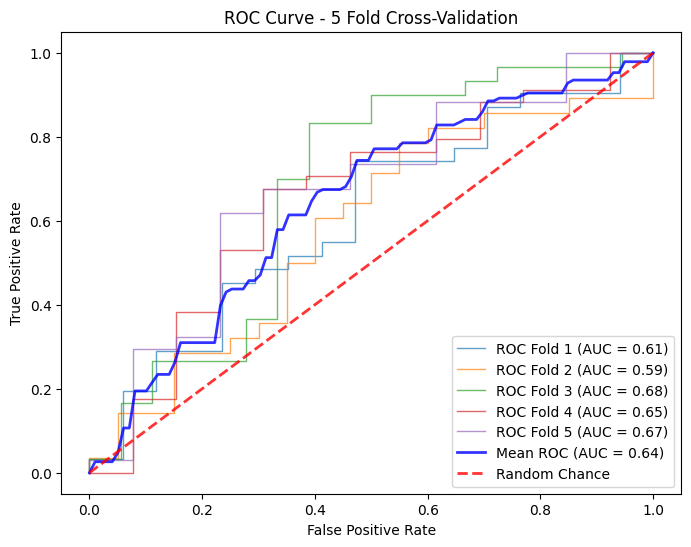

In [104]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import KFold
import numpy as np

# Assuming you have your data and model ready
# X = x_reduced

# x_train,x_test,y_train,y_test = pd.DataFrame(x_train),pd.DataFrame(x_test),pd.DataFrame(y_train),pd.DataFrame(y_test)
# X = pd.concat([x_train,x_test])
# y = pd.concat([y_train,y_test])
# y = your_labels  # Target variable
X = x_reduced
# Initialize KFold with 5 folds
kf = KFold(n_splits=5, shuffle=True, random_state=42)

plt.figure(figsize=(8, 6))

# Initialize variables to store mean values of true positive rates (tprs) and area under curve (aucs)
mean_tpr = 0.0
mean_fpr = np.linspace(0, 1, 100)
all_tpr = []

for i, (train_index, test_index) in enumerate(kf.split(X)):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Fit your model
    model.fit(X_train, y_train)

    # Predict probabilities for positive class
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Compute ROC curve and area under the curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve for this fold
    plt.plot(fpr, tpr, lw=1, alpha=0.7,
             label=f'ROC Fold {i+1} (AUC = {roc_auc:.2f})')

    # Interpolate tpr at mean_fpr
    mean_tpr += np.interp(mean_fpr, fpr, tpr)
    mean_tpr[0] = 0.0

# Calculate mean of tprs and auc across all folds
mean_tpr /= kf.get_n_splits(X)
mean_auc = auc(mean_fpr, mean_tpr)

# Plot mean ROC curve
plt.plot(mean_fpr, mean_tpr, color='b',
         label=f'Mean ROC (AUC = {mean_auc:.2f})', lw=2, alpha=0.8)

# Plot the random chance line
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
         label='Random Chance', alpha=.8)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - 5 Fold Cross-Validation')
plt.legend(loc='lower right')
plt.show()


0:	learn: 0.6906326	total: 2.08ms	remaining: 3.12s
1:	learn: 0.6877965	total: 4.08ms	remaining: 3.06s
2:	learn: 0.6836662	total: 5.53ms	remaining: 2.76s
3:	learn: 0.6813453	total: 7.49ms	remaining: 2.8s
4:	learn: 0.6778867	total: 8.84ms	remaining: 2.64s
5:	learn: 0.6748303	total: 10.1ms	remaining: 2.51s
6:	learn: 0.6718515	total: 11.3ms	remaining: 2.42s
7:	learn: 0.6691810	total: 12.7ms	remaining: 2.36s
8:	learn: 0.6666268	total: 14ms	remaining: 2.32s
9:	learn: 0.6643106	total: 15.2ms	remaining: 2.27s
10:	learn: 0.6611608	total: 16.4ms	remaining: 2.21s
11:	learn: 0.6581844	total: 17.5ms	remaining: 2.18s
12:	learn: 0.6560769	total: 18.7ms	remaining: 2.14s
13:	learn: 0.6529241	total: 19.9ms	remaining: 2.12s
14:	learn: 0.6510286	total: 21.2ms	remaining: 2.1s
15:	learn: 0.6483423	total: 22.5ms	remaining: 2.09s
16:	learn: 0.6451555	total: 23.8ms	remaining: 2.07s
17:	learn: 0.6428642	total: 25.1ms	remaining: 2.07s
18:	learn: 0.6408391	total: 26.4ms	remaining: 2.06s
19:	learn: 0.6379000	total

251:	learn: 0.4232793	total: 382ms	remaining: 1.89s
252:	learn: 0.4229383	total: 384ms	remaining: 1.89s
253:	learn: 0.4223486	total: 386ms	remaining: 1.89s
254:	learn: 0.4218883	total: 387ms	remaining: 1.89s
255:	learn: 0.4217270	total: 390ms	remaining: 1.89s
256:	learn: 0.4213643	total: 392ms	remaining: 1.89s
257:	learn: 0.4208590	total: 394ms	remaining: 1.9s
258:	learn: 0.4203082	total: 397ms	remaining: 1.9s
259:	learn: 0.4195974	total: 399ms	remaining: 1.9s
260:	learn: 0.4192571	total: 402ms	remaining: 1.91s
261:	learn: 0.4189684	total: 404ms	remaining: 1.91s
262:	learn: 0.4178915	total: 406ms	remaining: 1.91s
263:	learn: 0.4174231	total: 408ms	remaining: 1.91s
264:	learn: 0.4168388	total: 410ms	remaining: 1.91s
265:	learn: 0.4164092	total: 412ms	remaining: 1.91s
266:	learn: 0.4159377	total: 413ms	remaining: 1.91s
267:	learn: 0.4154931	total: 414ms	remaining: 1.9s
268:	learn: 0.4151611	total: 416ms	remaining: 1.9s
269:	learn: 0.4145818	total: 417ms	remaining: 1.9s
270:	learn: 0.4141

508:	learn: 0.3297946	total: 763ms	remaining: 1.49s
509:	learn: 0.3293871	total: 765ms	remaining: 1.49s
510:	learn: 0.3288371	total: 767ms	remaining: 1.48s
511:	learn: 0.3287240	total: 769ms	remaining: 1.48s
512:	learn: 0.3284781	total: 772ms	remaining: 1.49s
513:	learn: 0.3281430	total: 775ms	remaining: 1.49s
514:	learn: 0.3279461	total: 777ms	remaining: 1.49s
515:	learn: 0.3275277	total: 780ms	remaining: 1.49s
516:	learn: 0.3274020	total: 783ms	remaining: 1.49s
517:	learn: 0.3270851	total: 785ms	remaining: 1.49s
518:	learn: 0.3267878	total: 788ms	remaining: 1.49s
519:	learn: 0.3266476	total: 790ms	remaining: 1.49s
520:	learn: 0.3264676	total: 792ms	remaining: 1.49s
521:	learn: 0.3263037	total: 793ms	remaining: 1.49s
522:	learn: 0.3261549	total: 794ms	remaining: 1.48s
523:	learn: 0.3260613	total: 796ms	remaining: 1.48s
524:	learn: 0.3257850	total: 797ms	remaining: 1.48s
525:	learn: 0.3255715	total: 799ms	remaining: 1.48s
526:	learn: 0.3252245	total: 800ms	remaining: 1.48s
527:	learn: 

758:	learn: 0.2576403	total: 1.16s	remaining: 1.13s
759:	learn: 0.2573454	total: 1.16s	remaining: 1.13s
760:	learn: 0.2569071	total: 1.16s	remaining: 1.13s
761:	learn: 0.2566022	total: 1.16s	remaining: 1.12s
762:	learn: 0.2565428	total: 1.16s	remaining: 1.12s
763:	learn: 0.2561703	total: 1.17s	remaining: 1.12s
764:	learn: 0.2558996	total: 1.17s	remaining: 1.12s
765:	learn: 0.2557326	total: 1.17s	remaining: 1.12s
766:	learn: 0.2555225	total: 1.18s	remaining: 1.13s
767:	learn: 0.2552743	total: 1.18s	remaining: 1.12s
768:	learn: 0.2551633	total: 1.18s	remaining: 1.12s
769:	learn: 0.2548403	total: 1.18s	remaining: 1.12s
770:	learn: 0.2544420	total: 1.19s	remaining: 1.12s
771:	learn: 0.2542652	total: 1.19s	remaining: 1.12s
772:	learn: 0.2540699	total: 1.19s	remaining: 1.12s
773:	learn: 0.2537448	total: 1.19s	remaining: 1.12s
774:	learn: 0.2535042	total: 1.19s	remaining: 1.11s
775:	learn: 0.2532286	total: 1.19s	remaining: 1.11s
776:	learn: 0.2529892	total: 1.2s	remaining: 1.11s
777:	learn: 0

949:	learn: 0.2123771	total: 1.54s	remaining: 889ms
950:	learn: 0.2121622	total: 1.54s	remaining: 888ms
951:	learn: 0.2118950	total: 1.54s	remaining: 887ms
952:	learn: 0.2118684	total: 1.54s	remaining: 885ms
953:	learn: 0.2117399	total: 1.54s	remaining: 884ms
954:	learn: 0.2114386	total: 1.55s	remaining: 882ms
955:	learn: 0.2113861	total: 1.55s	remaining: 881ms
956:	learn: 0.2112791	total: 1.55s	remaining: 880ms
957:	learn: 0.2110354	total: 1.55s	remaining: 879ms
958:	learn: 0.2108631	total: 1.56s	remaining: 878ms
959:	learn: 0.2107413	total: 1.56s	remaining: 876ms
960:	learn: 0.2105994	total: 1.56s	remaining: 874ms
961:	learn: 0.2105082	total: 1.56s	remaining: 873ms
962:	learn: 0.2104428	total: 1.56s	remaining: 871ms
963:	learn: 0.2103087	total: 1.56s	remaining: 869ms
964:	learn: 0.2101697	total: 1.56s	remaining: 868ms
965:	learn: 0.2099459	total: 1.57s	remaining: 866ms
966:	learn: 0.2098811	total: 1.57s	remaining: 865ms
967:	learn: 0.2095773	total: 1.57s	remaining: 863ms
968:	learn: 

...

447:	learn: 0.3831254	total: 666ms	remaining: 1.56s
448:	learn: 0.3825418	total: 668ms	remaining: 1.56s
449:	learn: 0.3822501	total: 670ms	remaining: 1.56s
450:	learn: 0.3820497	total: 672ms	remaining: 1.56s
451:	learn: 0.3815800	total: 693ms	remaining: 1.61s
452:	learn: 0.3812887	total: 697ms	remaining: 1.61s
453:	learn: 0.3808767	total: 699ms	remaining: 1.61s
454:	learn: 0.3806614	total: 702ms	remaining: 1.61s
455:	learn: 0.3801186	total: 704ms	remaining: 1.61s
456:	learn: 0.3795611	total: 706ms	remaining: 1.61s
457:	learn: 0.3791699	total: 708ms	remaining: 1.61s
458:	learn: 0.3789720	total: 710ms	remaining: 1.61s
459:	learn: 0.3786766	total: 712ms	remaining: 1.61s
460:	learn: 0.3782824	total: 713ms	remaining: 1.61s
461:	learn: 0.3780350	total: 716ms	remaining: 1.61s
462:	learn: 0.3776319	total: 718ms	remaining: 1.61s
463:	learn: 0.3773299	total: 720ms	remaining: 1.61s
464:	learn: 0.3770162	total: 722ms	remaining: 1.61s
465:	learn: 0.3766463	total: 724ms	remaining: 1.61s
466:	learn: 

644:	learn: 0.3175837	total: 1.05s	remaining: 1.39s
645:	learn: 0.3172197	total: 1.05s	remaining: 1.39s
646:	learn: 0.3168768	total: 1.05s	remaining: 1.39s
647:	learn: 0.3166126	total: 1.05s	remaining: 1.39s
648:	learn: 0.3163186	total: 1.06s	remaining: 1.39s
649:	learn: 0.3162422	total: 1.06s	remaining: 1.39s
650:	learn: 0.3159373	total: 1.06s	remaining: 1.39s
651:	learn: 0.3155556	total: 1.06s	remaining: 1.38s
652:	learn: 0.3152529	total: 1.07s	remaining: 1.38s
653:	learn: 0.3151624	total: 1.07s	remaining: 1.38s
654:	learn: 0.3148328	total: 1.07s	remaining: 1.38s
655:	learn: 0.3145767	total: 1.07s	remaining: 1.38s
656:	learn: 0.3143597	total: 1.07s	remaining: 1.38s
657:	learn: 0.3141839	total: 1.07s	remaining: 1.38s
658:	learn: 0.3141136	total: 1.08s	remaining: 1.37s
659:	learn: 0.3139159	total: 1.08s	remaining: 1.37s
660:	learn: 0.3135682	total: 1.08s	remaining: 1.37s
661:	learn: 0.3134686	total: 1.08s	remaining: 1.37s
662:	learn: 0.3131273	total: 1.08s	remaining: 1.36s
663:	learn: 

900:	learn: 0.2453762	total: 1.43s	remaining: 954ms
901:	learn: 0.2449403	total: 1.44s	remaining: 953ms
902:	learn: 0.2447845	total: 1.44s	remaining: 951ms
903:	learn: 0.2444912	total: 1.44s	remaining: 950ms
904:	learn: 0.2441656	total: 1.44s	remaining: 950ms
905:	learn: 0.2439075	total: 1.45s	remaining: 949ms
906:	learn: 0.2436967	total: 1.45s	remaining: 948ms
907:	learn: 0.2433221	total: 1.45s	remaining: 947ms
908:	learn: 0.2430654	total: 1.46s	remaining: 947ms
909:	learn: 0.2428766	total: 1.46s	remaining: 946ms
910:	learn: 0.2426579	total: 1.46s	remaining: 944ms
911:	learn: 0.2423512	total: 1.46s	remaining: 942ms
912:	learn: 0.2421897	total: 1.46s	remaining: 940ms
913:	learn: 0.2418694	total: 1.47s	remaining: 939ms
914:	learn: 0.2417127	total: 1.47s	remaining: 938ms
915:	learn: 0.2415286	total: 1.47s	remaining: 937ms
916:	learn: 0.2412227	total: 1.47s	remaining: 935ms
917:	learn: 0.2409392	total: 1.47s	remaining: 934ms
918:	learn: 0.2408881	total: 1.47s	remaining: 932ms
919:	learn: 

1089:	learn: 0.2041350	total: 1.82s	remaining: 684ms
1090:	learn: 0.2040149	total: 1.82s	remaining: 682ms
1091:	learn: 0.2037389	total: 1.82s	remaining: 681ms
1092:	learn: 0.2034402	total: 1.82s	remaining: 679ms
1093:	learn: 0.2032821	total: 1.82s	remaining: 678ms
1094:	learn: 0.2032364	total: 1.83s	remaining: 676ms
1095:	learn: 0.2030771	total: 1.83s	remaining: 675ms
1096:	learn: 0.2028834	total: 1.83s	remaining: 673ms
1097:	learn: 0.2027176	total: 1.83s	remaining: 672ms
1098:	learn: 0.2026302	total: 1.84s	remaining: 670ms
1099:	learn: 0.2024045	total: 1.84s	remaining: 669ms
1100:	learn: 0.2021375	total: 1.84s	remaining: 667ms
1101:	learn: 0.2018604	total: 1.84s	remaining: 665ms
1102:	learn: 0.2017614	total: 1.84s	remaining: 663ms
1103:	learn: 0.2015966	total: 1.84s	remaining: 662ms
1104:	learn: 0.2015449	total: 1.84s	remaining: 660ms
1105:	learn: 0.2012999	total: 1.85s	remaining: 658ms
1106:	learn: 0.2010122	total: 1.85s	remaining: 656ms
1107:	learn: 0.2008412	total: 1.85s	remaining:

1339:	learn: 0.1618750	total: 2.2s	remaining: 262ms
1340:	learn: 0.1617467	total: 2.2s	remaining: 261ms
1341:	learn: 0.1615782	total: 2.2s	remaining: 259ms
1342:	learn: 0.1613872	total: 2.2s	remaining: 258ms
1343:	learn: 0.1613283	total: 2.2s	remaining: 256ms
1344:	learn: 0.1611415	total: 2.21s	remaining: 254ms
1345:	learn: 0.1609052	total: 2.21s	remaining: 253ms
1346:	learn: 0.1608183	total: 2.21s	remaining: 251ms
1347:	learn: 0.1607503	total: 2.21s	remaining: 250ms
1348:	learn: 0.1606172	total: 2.22s	remaining: 248ms
1349:	learn: 0.1605666	total: 2.22s	remaining: 247ms
1350:	learn: 0.1603792	total: 2.22s	remaining: 245ms
1351:	learn: 0.1602165	total: 2.22s	remaining: 243ms
1352:	learn: 0.1601286	total: 2.22s	remaining: 242ms
1353:	learn: 0.1599737	total: 2.22s	remaining: 240ms
1354:	learn: 0.1598327	total: 2.23s	remaining: 238ms
1355:	learn: 0.1595922	total: 2.23s	remaining: 237ms
1356:	learn: 0.1594463	total: 2.23s	remaining: 235ms
1357:	learn: 0.1593276	total: 2.23s	remaining: 233m

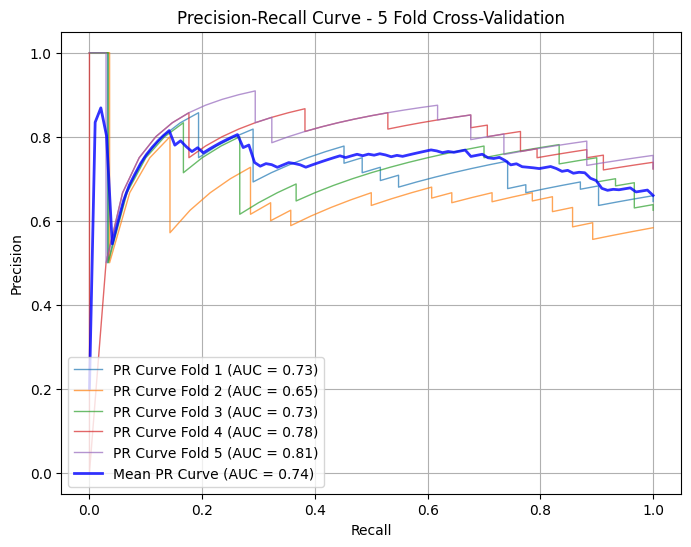

In [105]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc
from sklearn.model_selection import KFold
import numpy as np

# Assuming you have your data and model ready
X = x_reduced  # Features
# y = yo  # Target variable

# Initialize KFold with 5 folds
kf = KFold(n_splits=5, shuffle=True, random_state=42)

plt.figure(figsize=(8, 6))

# Initialize variables to store mean values of precision, recall, and area under curve (auc)
mean_precision = 0.0
mean_recall = np.linspace(0, 1, 100)
all_precision = []

for i, (train_index, test_index) in enumerate(kf.split(X)):
    X_train, X_test = X[train_index], X[test_index]
    Y_train, Y_test = y.iloc[train_index], y.iloc[test_index]

    # Fit your model
    model.fit(X_train, Y_train)

    # Predict probabilities for positive class
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Compute Precision-Recall curve and area under the curve
    precision, recall, _ = precision_recall_curve(Y_test, y_pred_proba)
    pr_auc = auc(recall, precision)

    # Plot PR curve for this fold
    plt.plot(recall, precision, lw=1, alpha=0.7,
             label=f'PR Curve Fold {i+1} (AUC = {pr_auc:.2f})')

    # Interpolate precision at mean_recall
    mean_precision += np.interp(mean_recall, recall[::-1], precision[::-1])
    mean_precision[0] = 1.0

# Calculate mean of precision, recall, and auc across all folds
mean_precision /= kf.get_n_splits(X)
mean_auc = auc(mean_recall, mean_precision)

# Plot mean PR curve
plt.plot(mean_recall, mean_precision, color='b',
         label=f'Mean PR Curve (AUC = {mean_auc:.2f})', lw=2, alpha=0.8)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - 5 Fold Cross-Validation')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()


# Dimensionlaity Reduction and Feature Selection Techniques

In [106]:
# !pip install boruta

In [107]:
#Applying BORUTA algorithm

# from sklearn.datasets import load_diabetes
from sklearn.ensemble import RandomForestRegressor
from boruta import BorutaPy
import pandas as pd
import numpy as np

# # let's load the load_diabetes() dataset from sklearn
# X, y = load_diabetes(return_X_y=True, as_frame=True)

# let's initialize a RF model 
model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=1)
model.fit(x,y)

# let's initialize Boruta
feat_selector = BorutaPy(
    verbose=2,
    estimator=model,
    n_estimators='auto',
    max_iter=10  # number of iterations to perform
   
)

# train Boruta
# N.B.: X and y must be numpy arrays
feat_selector.fit(np.array(x), np.array(y))

# print support and ranking for each feature
print("\n------Support and Ranking for each feature------")
for i in range(len(feat_selector.support_)):
    if feat_selector.support_[i]:
        print("Passes the test: ", X.columns[i],
              " - Ranking: ", feat_selector.ranking_[i])
    else:
        print("Doesn't pass the test: ",
              X.columns[i], " - Ranking: ", feat_selector.ranking_[i])

Iteration: 	1 / 10
Confirmed: 	0
Tentative: 	32
Rejected: 	0
Iteration: 	2 / 10
Confirmed: 	0
Tentative: 	32
Rejected: 	0
Iteration: 	3 / 10
Confirmed: 	0
Tentative: 	32
Rejected: 	0
Iteration: 	4 / 10
Confirmed: 	0
Tentative: 	32
Rejected: 	0
Iteration: 	5 / 10
Confirmed: 	0
Tentative: 	32
Rejected: 	0
Iteration: 	6 / 10
Confirmed: 	0
Tentative: 	32
Rejected: 	0
Iteration: 	7 / 10
Confirmed: 	0
Tentative: 	32
Rejected: 	0
Iteration: 	8 / 10
Confirmed: 	0
Tentative: 	5
Rejected: 	27
Iteration: 	9 / 10
Confirmed: 	2
Tentative: 	3
Rejected: 	27


BorutaPy finished running.

Iteration: 	10 / 10
Confirmed: 	2
Tentative: 	2
Rejected: 	27

------Support and Ranking for each feature------


AttributeError: 'numpy.ndarray' object has no attribute 'columns'

In [ ]:
sel_col = pd.Series(feat_selector.ranking_,index=x.columns)
sel_col.sort_values(inplace=True)

In [ ]:
sel_col.plot(kind='bar',yticks=np.arange(33)) #It gives rank so aork accordingly

In [ ]:
df2.info()

In [ ]:
brt15 = sel_col[sel_col.values<16]
brt15.index

In [ ]:
# ruk jaana yaha....

## Shap Value

In [ ]:
# !pip install shap

In [ ]:
import shap
model.fit(x_train,y_train)
explainer = shap.Explainer(model.predict, x_test)
shap_values = explainer(x_test)


In [ ]:
shap.plots.bar(shap_values)

In [ ]:
shap.plots.waterfall(shap_values[0])

In [ ]:
shap.plots.beeswarm(shap_values)

In [ ]:
cols =["Appendix_Diameter","Alvarado_Score","Paedriatic_Appendicitis_Score","Thrombocyte_Count","Coughing_Pain","CRP",
       "WBC_Count","Height","Peritonitis_binary"] 
cols

In [ ]:
# error

## Information Gain

In [ ]:
from sklearn.feature_selection import mutual_info_classif
import matplotlib.pyplot as plt

importance = mutual_info_classif(x,y,random_state=0)
feat_importance = pd.Series(importance, x.columns[0:len(x.columns)])
feat_importance.plot(kind='barh',color = 'teal')

In [ ]:
mutual_info = pd.Series(importance)
mutual_info.index = x.columns
mutual_info.sort_values(ascending=False)

In [ ]:
# from sklearn.feature_selection import SelectKBest
# sel_five_cols = SelectKBest(mutual_info_classif, k=0.9)
# sel_five_cols.fit(x_train, y_train)
# x_train.columns[sel_five_cols.get_support()]

In [ ]:
cols = mutual_info[mutual_info>0].index
cols
# x = x.loc[:,cols]
# x.shape

In [ ]:
df3 = df.loc[:,cols]
df3.dropna(inplace =True)

In [ ]:
df3.shape

# Applying Fisher Score for feature selection

In [ ]:
# pip install skfeature-chappers

In [ ]:
# from skfeature.feat_selection import fisher_score
from skfeature.function.similarity_based import fisher_score
ranks = fisher_score.fisher_score(np.array(x),np.array(y))
feat_importance = pd.Series(ranks, x.columns[0:len(x.columns)])
fi = feat_importance.sort_values()
fi.plot(kind='barh',color = 'teal')
cols = ranks[ranks<25]

In [ ]:
cols

In [ ]:
x_= x.iloc[:, cols]
print("The features retained after using this techniques are :")
print(x_.columns)
df3.shape

## Variance Threshold as Feature Selection

In [ ]:
from sklearn.feature_selection import VarianceThreshold
v_threshold = VarianceThreshold(threshold=0.2)
x2 = v_threshold.fit_transform(x)
x2.shape

In [ ]:
mask = v_threshold.get_support(indices=True)
selected_cols = x.loc[:,x.columns[mask]]
selected_cols.columns

In [ ]:
v_threshold = VarianceThreshold(threshold=0.4)
x2 = v_threshold.fit_transform(x)
x2.shape

In [ ]:
mask = v_threshold.get_support(indices=True)
selected_cols = x.loc[:,x.columns[mask]]
selected_cols.columns

## Chi-square Test

In [ ]:
x.columns
non_cat = ["Age","BMI","Height","Weight","Appendix_Diameter","RBC_Count","Body_Temperature"]
x1 = x.drop(non_cat,axis=1)

In [ ]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
#Convert to catregorial data by converting data to integers
X_cat = x1.astype(int)

#three features with highest chi-squared statistics are selected
chi2_features = SelectKBest(chi2, k =15)
X_best_features = chi2_features.fit_transform(X_cat,y)

#Reduced features
print('Original feature number :',X_cat.shape[1])
print('Reduced feature number :',X_best_features.shape[1])

In [ ]:
X_best_features
selected_features = x1.columns[:][chi2_features.get_support()] 
print("\nSelected Features:") 
print(selected_features)

In [ ]:
non_cat(Index)

In [ ]:
cols = df2.columns
num_cols = df._get_numeric_data().columns
print(num_cols)
# Out[68]: Index([u'0', u'1', u'2'], dtype='object')
list(set(cols) - set(num_cols))